In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display

def _find_repo_root() -> Path:
    candidates = [Path.cwd().resolve()]
    try:
        candidates.append(Path(__file__).resolve().parent)
    except NameError:
        pass

    seen = set()
    for start in candidates:
        current = start
        while current not in seen:
            seen.add(current)
            if (current / 'src' / 'vehicle_telemetry').exists():
                return current
            if current.parent == current:
                break
            current = current.parent
    raise RuntimeError('Could not find repo root containing src/vehicle_telemetry')

ROOT = _find_repo_root()
sys.path.append(str(ROOT / 'src'))

from vehicle_telemetry.longitudinal import (
    BUCKETS,
    baseline_comparison,
    generate_report_markdown,
    latest_by_bucket,
    load_events,
    select_baseline,
    summarize_all_logs,
    write_outputs,
)

FA20DIT_ZONES = {
    'dam': [(0.0, 0.75, 'tab:red', 'concerning'), (0.75, 0.875, 'darkorange', 'investigate'), (0.875, 0.999, 'goldenrod', 'moderate'), (0.999, 1.05, 'tab:green', 'ideal')],
    'fbk': [(-8.0, -2.8, 'tab:red', 'danger'), (-2.8, -1.4, 'goldenrod', 'moderate'), (-1.4, 1.0, 'tab:green', 'ideal')],
    'fkl': [(-8.0, -2.8, 'tab:red', 'danger'), (-2.8, -1.4, 'goldenrod', 'moderate'), (-1.4, 1.0, 'tab:green', 'ideal')],
    'coolant_c': [(0.0, 98.0, 'tab:green', 'ideal'), (98.0, 105.0, 'goldenrod', 'moderate'), (105.0, 130.0, 'tab:red', 'danger')],
    'iat_c': [(0.0, 40.0, 'tab:green', 'ideal'), (40.0, 55.0, 'goldenrod', 'moderate'), (55.0, 100.0, 'tab:red', 'danger')],
    'trim_pct': [(-20.0, -10.0, 'tab:red', 'danger'), (-10.0, -5.0, 'goldenrod', 'moderate'), (-5.0, 5.0, 'tab:green', 'ideal'), (5.0, 8.0, 'goldenrod', 'moderate'), (8.0, 20.0, 'tab:red', 'danger')],
    'load_proxy': [(0.0, 10.0, 'tab:green', 'light'), (10.0, 20.0, 'goldenrod', 'moderate'), (20.0, 35.0, 'tab:orange', 'high'), (35.0, 80.0, 'tab:red', 'very high')],
}

events_path = ROOT / 'data' / 'events.csv'
raw_dir = ROOT / 'data' / 'raw'
output_dir = ROOT / 'outputs'

events_df = load_events(events_path)
summary_df, frames = summarize_all_logs(raw_dir, events_df)
if summary_df.empty:
    raise RuntimeError(f'No CSV logs found in {raw_dir}')
summary_df = summary_df.sort_values('log_datetime').reset_index(drop=True)
latest_map = latest_by_bucket(summary_df)
baseline_map = {bucket: select_baseline(summary_df, latest_map[bucket]) for bucket in BUCKETS}
report_md = generate_report_markdown(summary_df, latest_map, baseline_map, events_df)
output_paths = write_outputs(summary_df, report_md, output_dir)

def _num_series(frame, col):
    return pd.to_numeric(frame.get(col), errors='coerce') if col in frame.columns else pd.Series(dtype=float)

def _bucket_rows():
    rows = []
    for bucket in BUCKETS:
        latest = latest_map[bucket]
        baseline = baseline_map[bucket]
        rows.append({
            'bucket': f'{bucket[0]}/{bucket[1]}',
            'latest_log': None if latest is None else latest['filename'],
            'log_datetime': None if latest is None else latest['log_datetime'],
            'baseline_count': len(baseline),
            'baseline_confidence': 'limited' if len(baseline) < 3 else 'normal',
        })
    return pd.DataFrame(rows)

def _metadata_table(latest_row):
    return pd.DataFrame([{
        'filename': latest_row['filename'],
        'log_datetime': latest_row['log_datetime'],
        'log_type': latest_row['log_type'],
        'session_type': latest_row['session_type'],
        'era_id': latest_row['era_id'],
        'datetime_source': latest_row['log_datetime_source'],
        'recent_event_context': latest_row.get('recent_event_context', ''),
    }])

def _bucket_history(bucket):
    return summary_df[(summary_df['log_type'] == bucket[0]) & (summary_df['session_type'] == bucket[1])].sort_values('log_datetime').copy()

def _plot_metric_trend(bucket, metric, title, ylabel):
    hist = _bucket_history(bucket)
    if metric not in hist.columns:
        return
    vals = pd.to_numeric(hist[metric], errors='coerce')
    hist = hist.assign(_metric=vals).dropna(subset=['_metric'])
    if hist.empty:
        return
    labels = [f"{row.filename}\n{pd.to_datetime(row.log_datetime).strftime('%Y-%m-%d')}" for row in hist.itertuples()]
    x = np.arange(len(hist))
    fig, ax = plt.subplots(figsize=(max(8.5, len(hist) * 1.6), 2.8))
    ax.plot(x, hist['_metric'], marker='o', lw=1.1, color='black')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Logs')
    plt.tight_layout()
    plt.show()

def _plot_trim_trend(bucket):
    hist = _bucket_history(bucket).copy()
    if hist.empty:
        return
    hist['mean_ltft_pct'] = pd.to_numeric(hist.get('mean_ltft_pct'), errors='coerce')
    hist['mean_stft_pct'] = pd.to_numeric(hist.get('mean_stft_pct'), errors='coerce')
    if hist[['mean_ltft_pct', 'mean_stft_pct']].dropna(how='all').empty:
        return
    labels = [f"{row.filename}\n{pd.to_datetime(row.log_datetime).strftime('%Y-%m-%d')}" for row in hist.itertuples()]
    x = np.arange(len(hist))
    fig, ax = plt.subplots(figsize=(max(8.5, len(hist) * 1.6), 2.8))
    if hist['mean_ltft_pct'].notna().any():
        ax.plot(x, hist['mean_ltft_pct'], marker='o', lw=1.0, label='mean LTFT', color='tab:brown')
    if hist['mean_stft_pct'].notna().any():
        ax.plot(x, hist['mean_stft_pct'], marker='o', lw=1.0, label='mean STFT', color='tab:purple')
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_title('Historical Fuel Trim Trend')
    ax.set_ylabel('Trim (%)')
    ax.set_xlabel('Logs')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

def _latest_cobb_row():
    cobb = [row for bucket, row in latest_map.items() if bucket[0] == "cobb" and row is not None]
    if not cobb:
        return None
    return sorted(cobb, key=lambda r: r['log_datetime'])[-1]

def _latest_overall_row():
    return summary_df.sort_values('log_datetime').iloc[-1] if not summary_df.empty else None

def _risk_label(color):
    return color

def _normal_range(metric):
    ranges = {
        'DAM': '1.00 ideal; 0.875-<1.00 moderate; 0.75-<0.875 investigate; <0.75 concerning',
        'FBK': '> -1.4 deg ideal; -1.4 to -2.8 deg moderate; < -2.8 deg concerning',
        'FKL': '> -1.4 deg ideal; -1.4 to -2.8 deg investigate; < -2.8 deg concerning',
        'Mean LTFT': '-5% to +5% typical; +/-5% to +/-8% moderate; beyond +/-8% investigate',
        'Mean STFT': '-5% to +5% typical; +/-5% to +/-8% moderate; beyond +/-8% investigate',
        'Max IAT': '<40 C ideal; 40-55 C moderate; >55 C concerning',
        'Max Coolant': '<98 C ideal; 98-105 C moderate; >105 C concerning',
        'Engine Demand': 'Light to very high, based on load proxy, MAP, and high-load exposure',
        'Risk Under Load': 'Low if loaded operation stays thermally stable and knock/timing remain quiet',
    }
    return ranges.get(metric, 'n/a')

def _style_summary_table(df):
    if df.empty:
        return HTML('<p>No summary metrics available.</p>')

    color_map = {
        'green': '#dff2e1',
        'yellow': '#fff4cc',
        'red': '#f8d7da',
        'gray': '#eceff3',
    }

    display_df = df.copy()
    if 'summary_stat' in display_df.columns:
        display_df['summary_stat'] = display_df['summary_stat'].map(
            lambda v: 'n/a' if pd.isna(v) else (f'{v:.3f}' if isinstance(v, (int, float, np.floating)) else str(v))
        )

    headers = ''.join(
        f"<th style='text-align:left; padding:6px 8px; border-bottom:1px solid #d0d7de'>{col}</th>"
        for col in display_df.columns
    )
    rows = []
    for _, row in display_df.iterrows():
        cells = []
        for col in display_df.columns:
            value = row[col]
            style = "padding:6px 8px; text-align:left; border-bottom:1px solid #eef2f6;"
            if col == 'risk':
                bg = color_map.get(str(value).lower(), '#ffffff')
                style += f" background-color:{bg}; font-weight:600;"
            cells.append(f"<td style='{style}'>{value}</td>")
        rows.append('<tr>' + ''.join(cells) + '</tr>')

    table_html = (
        "<table style='border-collapse:collapse; width:100%; font-size:13px'>"
        + f"<thead><tr>{headers}</tr></thead>"
        + f"<tbody>{''.join(rows)}</tbody></table>"
    )
    return HTML(table_html)

def _dam_status(value):
    if pd.isna(value):
        return ('n/a', 'gray')
    if value < 0.75:
        return ('concerning', 'red')
    if value < 0.875:
        return ('investigate', 'yellow')
    if value < 1.0:
        return ('moderate', 'yellow')
    return ('ideal', 'green')

def _knock_status(value):
    if pd.isna(value):
        return ('n/a', 'gray')
    if value <= -2.8:
        return ('deep correction', 'red')
    if value <= -1.4:
        return ('meaningful correction', 'yellow')
    return ('quiet', 'green')

def _trim_status(value):
    if pd.isna(value):
        return ('n/a', 'gray')
    av = abs(value)
    if av > 8:
        return ('biased', 'red')
    if av > 5:
        return ('elevated', 'yellow')
    return ('stable', 'green')

def _iat_status(value):
    if pd.isna(value):
        return ('n/a', 'gray')
    if value > 55:
        return ('hot', 'red')
    if value > 40:
        return ('elevated', 'yellow')
    return ('normal', 'green')

def _coolant_status(value):
    if pd.isna(value):
        return ('n/a', 'gray')
    if value > 105:
        return ('hot', 'red')
    if value > 98:
        return ('elevated', 'yellow')
    return ('normal', 'green')

def _load_status(value):
    if pd.isna(value):
        return ('n/a', 'gray')
    if value >= 40:
        return ('very high', 'red')
    if value >= 25:
        return ('high', 'yellow')
    if value >= 15:
        return ('moderate', 'green')
    return ('light', 'green')

def _engine_demand_status(max_load, p95_load, high_load_pct, max_map):
    max_load = pd.to_numeric(pd.Series([max_load]), errors='coerce').iloc[0]
    p95_load = pd.to_numeric(pd.Series([p95_load]), errors='coerce').iloc[0]
    high_load_pct = pd.to_numeric(pd.Series([high_load_pct]), errors='coerce').iloc[0]
    max_map = pd.to_numeric(pd.Series([max_map]), errors='coerce').iloc[0]
    if pd.isna(max_load) and pd.isna(p95_load) and pd.isna(high_load_pct) and pd.isna(max_map):
        return ('n/a', 'gray')
    if ((pd.notna(max_load) and max_load >= 40) or (pd.notna(p95_load) and p95_load >= 28) or (pd.notna(high_load_pct) and high_load_pct >= 18) or (pd.notna(max_map) and max_map >= 240)):
        return ('very high', 'red')
    if ((pd.notna(max_load) and max_load >= 25) or (pd.notna(p95_load) and p95_load >= 18) or (pd.notna(high_load_pct) and high_load_pct >= 8) or (pd.notna(max_map) and max_map >= 210)):
        return ('high', 'yellow')
    if ((pd.notna(max_load) and max_load >= 15) or (pd.notna(p95_load) and p95_load >= 12) or (pd.notna(high_load_pct) and high_load_pct >= 3) or (pd.notna(max_map) and max_map >= 170)):
        return ('moderate', 'green')
    return ('light', 'green')

def _risk_under_load_status(row):
    min_dam = pd.to_numeric(pd.Series([row.get('min_dam')]), errors='coerce').iloc[0]
    min_fbk = pd.to_numeric(pd.Series([row.get('min_fbk')]), errors='coerce').iloc[0]
    min_fkl = pd.to_numeric(pd.Series([row.get('min_fkl')]), errors='coerce').iloc[0]
    fbk_count = pd.to_numeric(pd.Series([row.get('meaningful_fbk_count')]), errors='coerce').iloc[0]
    fkl_count = pd.to_numeric(pd.Series([row.get('meaningful_fkl_count')]), errors='coerce').iloc[0]
    max_iat = pd.to_numeric(pd.Series([row.get('max_iat_c')]), errors='coerce').iloc[0]
    max_coolant = pd.to_numeric(pd.Series([row.get('max_coolant_c')]), errors='coerce').iloc[0]
    mean_ltft = pd.to_numeric(pd.Series([row.get('mean_ltft_pct')]), errors='coerce').iloc[0]
    mean_stft = pd.to_numeric(pd.Series([row.get('mean_stft_pct')]), errors='coerce').iloc[0]
    high_load_pct = pd.to_numeric(pd.Series([row.get('high_load_pct')]), errors='coerce').iloc[0]
    max_load = pd.to_numeric(pd.Series([row.get('max_load_proxy')]), errors='coerce').iloc[0]

    loaded = ((pd.notna(high_load_pct) and high_load_pct >= 3) or (pd.notna(max_load) and max_load >= 15))
    issue_count = 0.0
    severe = False

    if pd.notna(min_dam) and min_dam < 0.875:
        issue_count += 1
        severe = severe or min_dam < 0.75
    if pd.notna(min_fbk) and min_fbk <= -2.8:
        issue_count += 1
        severe = True
    elif pd.notna(min_fbk) and min_fbk <= -2.0:
        issue_count += 1
    if pd.notna(min_fkl) and min_fkl <= -2.8:
        issue_count += 1
        severe = True
    elif pd.notna(min_fkl) and min_fkl <= -1.4:
        issue_count += 1
    if pd.notna(fbk_count) and fbk_count >= 2:
        issue_count += 1
    if pd.notna(fkl_count) and fkl_count >= 2:
        issue_count += 1
    if pd.notna(max_iat) and max_iat > 55:
        issue_count += 1
        severe = True
    elif pd.notna(max_iat) and max_iat > 40:
        issue_count += 0.5
    if pd.notna(max_coolant) and max_coolant > 105:
        issue_count += 1
        severe = True
    elif pd.notna(max_coolant) and max_coolant > 98:
        issue_count += 0.5
    if pd.notna(mean_ltft) and abs(mean_ltft) > 8:
        issue_count += 1
    elif pd.notna(mean_ltft) and abs(mean_ltft) > 5:
        issue_count += 0.5
    if pd.notna(mean_stft) and abs(mean_stft) > 8:
        issue_count += 1
    elif pd.notna(mean_stft) and abs(mean_stft) > 5:
        issue_count += 0.5

    if not loaded and issue_count == 0:
        return ('low', 'green')
    if severe or (loaded and issue_count >= 3):
        return ('high', 'red')
    if issue_count >= 1.5:
        return ('investigate', 'yellow')
    if issue_count > 0:
        return ('watch', 'yellow')
    return ('low', 'green')

def _count_true_runs_local(mask):
    vals = pd.Series(mask).fillna(False).astype(bool).to_numpy()
    count = 0
    prev = False
    for v in vals:
        if v and not prev:
            count += 1
        prev = bool(v)
    return count

def _drive_coverage_metrics(frame):
    dt = _num_series(frame, 'dt_s').fillna(0.0)
    if dt.empty:
        dt = pd.Series(np.zeros(len(frame)), index=frame.index, dtype=float)
    state = frame.get('state', pd.Series('cruise', index=frame.index)).astype(str)
    speed = _num_series(frame, 'speed_mph')
    if speed.empty:
        speed = _num_series(frame, 'speed_kph') * 0.621371192237334
    throttle = _num_series(frame, 'throttle_pct')
    rpm = _num_series(frame, 'rpm')
    load = _num_series(frame, 'load_proxy')

    duration_s = float(dt.sum())
    moving_mask = speed > 3.0 if speed.notna().any() else state.ne('idle')
    moving_time_s = float(dt.where(moving_mask, 0.0).sum())

    state_times = {}
    for label in ['idle', 'cruise', 'accel', 'decel']:
        state_times[f'{label}_time_s'] = float(dt.where(state == label, 0.0).sum())

    p95_load = float(load.quantile(0.95)) if load.notna().any() else np.nan
    high_load_mask = (load > p95_load) if np.isfinite(p95_load) else pd.Series(False, index=frame.index)
    high_load_time_s = float(dt.where(high_load_mask, 0.0).sum())
    high_load_pct = (high_load_time_s / duration_s * 100.0) if duration_s > 0 else np.nan

    pull_mask = ((state == 'accel') & (throttle > 40) & (rpm > 2500))
    pull_count = _count_true_runs_local(pull_mask)
    longest_pull_s = 0.0
    run_total = 0.0
    for active, sample_dt in zip(pull_mask.fillna(False).to_numpy(), dt.to_numpy()):
        if active:
            run_total += float(sample_dt)
            longest_pull_s = max(longest_pull_s, run_total)
        else:
            run_total = 0.0

    pct_rpm_2500 = float((rpm > 2500).mean() * 100.0) if rpm.notna().any() else np.nan
    pct_rpm_3500 = float((rpm > 3500).mean() * 100.0) if rpm.notna().any() else np.nan
    pct_throttle_25 = float((throttle > 25).mean() * 100.0) if throttle.notna().any() else np.nan
    pct_throttle_60 = float((throttle > 60).mean() * 100.0) if throttle.notna().any() else np.nan

    if duration_s < 180 or moving_time_s < 120 or (np.isfinite(pct_rpm_2500) and pct_rpm_2500 < 5):
        confidence = 'low'
        risk = 'yellow'
    elif duration_s < 480 or (np.isfinite(pct_throttle_25) and pct_throttle_25 < 8) or (np.isfinite(pct_rpm_3500) and pct_rpm_3500 < 3):
        confidence = 'medium'
        risk = 'yellow'
    else:
        confidence = 'high'
        risk = 'green'

    if duration_s > 0:
        idle_pct = state_times['idle_time_s'] / duration_s * 100.0
        accel_pct = state_times['accel_time_s'] / duration_s * 100.0
    else:
        idle_pct = np.nan
        accel_pct = np.nan

    if confidence == 'low':
        interpretation = 'This log provides limited coverage. A clean latest log here should not be treated as strong evidence that the car is issue-free.'
    elif confidence == 'medium':
        interpretation = 'This log has moderate coverage. It is useful for context, but the absence of anomalies is still less informative than a longer log with more loaded operation.'
    elif np.isfinite(accel_pct) and accel_pct > 10:
        interpretation = 'This log has strong coverage with meaningful acceleration exposure, so the latest-log observations are reasonably informative.'
    else:
        interpretation = 'This log has good overall length, but it is still weighted toward easier operation than repeated loaded pulls.'

    summary_stat = f'{duration_s/60.0:.1f} min total; {moving_time_s/60.0:.1f} min moving; {pull_count} pulls'

    metrics = {
        'duration_s': duration_s,
        'moving_time_s': moving_time_s,
        'idle_time_s': state_times['idle_time_s'],
        'cruise_time_s': state_times['cruise_time_s'],
        'accel_time_s': state_times['accel_time_s'],
        'decel_time_s': state_times['decel_time_s'],
        'high_load_time_s': high_load_time_s,
        'high_load_pct': high_load_pct,
        'pull_count': pull_count,
        'longest_pull_s': longest_pull_s,
        'pct_rpm_gt_2500': pct_rpm_2500,
        'pct_rpm_gt_3500': pct_rpm_3500,
        'pct_throttle_gt_25': pct_throttle_25,
        'pct_throttle_gt_60': pct_throttle_60,
        'coverage_confidence': confidence,
        'coverage_risk': risk,
        'summary_stat': summary_stat,
        'interpretation': interpretation,
    }
    return metrics

def _drive_coverage_table(frame):
    cov = _drive_coverage_metrics(frame)
    return pd.DataFrame([
        {'metric': 'Total duration (min)', 'value': round(cov['duration_s'] / 60.0, 2)},
        {'metric': 'Moving time (min)', 'value': round(cov['moving_time_s'] / 60.0, 2)},
        {'metric': 'Idle time (min)', 'value': round(cov['idle_time_s'] / 60.0, 2)},
        {'metric': 'Cruise time (min)', 'value': round(cov['cruise_time_s'] / 60.0, 2)},
        {'metric': 'Accel time (min)', 'value': round(cov['accel_time_s'] / 60.0, 2)},
        {'metric': 'Decel time (min)', 'value': round(cov['decel_time_s'] / 60.0, 2)},
        {'metric': 'High-load time (min)', 'value': round(cov['high_load_time_s'] / 60.0, 2)},
        {'metric': 'High-load share (%)', 'value': round(cov['high_load_pct'], 1) if pd.notna(cov['high_load_pct']) else np.nan},
        {'metric': 'Estimated pulls', 'value': int(cov['pull_count'])},
        {'metric': 'Longest pull (s)', 'value': round(cov['longest_pull_s'], 1)},
        {'metric': 'Samples above 2500 rpm (%)', 'value': round(cov['pct_rpm_gt_2500'], 1) if pd.notna(cov['pct_rpm_gt_2500']) else np.nan},
        {'metric': 'Samples above 3500 rpm (%)', 'value': round(cov['pct_rpm_gt_3500'], 1) if pd.notna(cov['pct_rpm_gt_3500']) else np.nan},
        {'metric': 'Throttle >25% (%)', 'value': round(cov['pct_throttle_gt_25'], 1) if pd.notna(cov['pct_throttle_gt_25']) else np.nan},
        {'metric': 'Throttle >60% (%)', 'value': round(cov['pct_throttle_gt_60'], 1) if pd.notna(cov['pct_throttle_gt_60']) else np.nan},
        {'metric': 'Coverage confidence', 'value': cov['coverage_confidence']},
    ])

def _plot_drive_coverage(frame):
    cov = _drive_coverage_metrics(frame)
    labels = ['Idle', 'Cruise', 'Accel', 'Decel']
    values = [cov['idle_time_s'] / 60.0, cov['cruise_time_s'] / 60.0, cov['accel_time_s'] / 60.0, cov['decel_time_s'] / 60.0]
    colors = ['#b8c1cc', '#8ab6d6', '#f4a261', '#a3be8c']
    fig, ax = plt.subplots(figsize=(8, 3.2))
    ax.bar(labels, values, color=colors)
    ax.set_ylabel('Minutes')
    ax.set_title('Drive Coverage by State')
    ax.text(0.99, 0.95, f"Coverage: {cov['coverage_confidence']}", transform=ax.transAxes, ha='right', va='top', fontsize=9)
    plt.tight_layout()
    plt.show()

def _display_drive_coverage(frame):
    cov = _drive_coverage_metrics(frame)
    display(Markdown('### Drive Coverage'))
    display(Markdown('Drive coverage summarizes how informative the latest session was. Short logs with little time above moderate throttle or mid-range RPM can look clean simply because they did not exercise the engine enough to reveal issues. This section separates useful latest-log coverage from sessions that should be treated as low-confidence snapshots.'))
    display(_drive_coverage_table(frame))
    _plot_drive_coverage(frame)
    display(Markdown(f"**Interpretation:** {cov['interpretation']}"))


WRX_GEAR_RATIOS = {1: 3.454, 2: 1.947, 3: 1.296, 4: 0.972, 5: 0.780, 6: 0.666}
WRX_FINAL_DRIVE = 4.111
WRX_TIRE_DIAMETER_IN = 25.3


def _estimate_gear(frame):
    rpm = _num_series(frame, 'rpm')
    speed = _num_series(frame, 'speed_mph')
    if speed.empty:
        speed = _num_series(frame, 'speed_kph') * 0.621371192237334
    wheel_rpm = speed * 336.0 / WRX_TIRE_DIAMETER_IN
    gear_ratio_obs = rpm / wheel_rpm.replace(0, np.nan)
    expected = {g: ratio * WRX_FINAL_DRIVE for g, ratio in WRX_GEAR_RATIOS.items()}
    est = []
    for obs, spd in zip(gear_ratio_obs, speed):
        if pd.isna(obs) or pd.isna(spd) or spd < 8:
            est.append(np.nan)
            continue
        best = min(expected, key=lambda g: abs(obs - expected[g]))
        if abs(obs - expected[best]) / expected[best] > 0.2:
            est.append(np.nan)
        else:
            est.append(best)
    return pd.Series(est, index=frame.index, name='gear_est')


def _knock_context_events(frame):
    fbk = _num_series(frame, 'fbk')
    fkl = _num_series(frame, 'fkl')
    dam = _num_series(frame, 'dam')
    throttle = _num_series(frame, 'throttle_pct')
    rpm = _num_series(frame, 'rpm')
    state = frame.get('state', pd.Series(index=frame.index, dtype=object)).astype(str)
    gear = _estimate_gear(frame)
    speed = _num_series(frame, 'speed_mph')
    if speed.empty:
        speed = _num_series(frame, 'speed_kph') * 0.621371192237334

    map_kpa = _num_series(frame, 'map_kpa')
    boost_actual_kpa = map_kpa - 101.325
    boost_actual_psi = boost_actual_kpa * 0.145038
    common = pd.DataFrame({
        'time_s': _num_series(frame, 'time_s'),
        'rpm': rpm,
        'gear_est': gear,
        'speed_mph': speed,
        'load_proxy': _num_series(frame, 'load_proxy'),
        'map_kpa': map_kpa,
        'boost_actual_kpa': boost_actual_kpa,
        'boost_actual_psi': boost_actual_psi,
        'boost_target_kpa': _num_series(frame, 'boost_target_kpa'),
        'boost_error_kpa': _num_series(frame, 'boost_error_kpa'),
        'throttle_pct': throttle,
        'iat_c': _num_series(frame, 'iat_c'),
        'state': state,
    })

    events = []
    fbk_mask = fbk <= -2.0
    if fbk_mask.any():
        part = common.loc[fbk_mask].copy()
        part['event_type'] = 'FBK'
        part['value'] = fbk.loc[fbk_mask].values
        events.append(part)

    fkl_mask = fkl <= -1.4
    if fkl_mask.any():
        part = common.loc[fkl_mask].copy()
        part['event_type'] = 'FKL'
        part['value'] = fkl.loc[fkl_mask].values
        events.append(part)

    dam_mask = (dam < 1.0) & (dam.diff().fillna(0).ne(0) | dam.eq(dam.min()))
    if dam_mask.any():
        part = common.loc[dam_mask].copy()
        part['event_type'] = 'DAM'
        part['value'] = dam.loc[dam_mask].values
        events.append(part)

    if not events:
        return pd.DataFrame(columns=['event_type', 'value', 'time_s', 'rpm', 'gear_est', 'speed_mph', 'load_proxy', 'map_kpa', 'boost_actual_kpa', 'boost_actual_psi', 'boost_target_kpa', 'boost_error_kpa', 'throttle_pct', 'iat_c', 'state'])

    out = pd.concat(events, ignore_index=True)
    out = out.sort_values(['time_s', 'event_type']).reset_index(drop=True)
    return out[['event_type', 'value', 'time_s', 'rpm', 'gear_est', 'speed_mph', 'load_proxy', 'map_kpa', 'boost_actual_kpa', 'boost_actual_psi', 'boost_target_kpa', 'boost_error_kpa', 'throttle_pct', 'iat_c', 'state']]


def _display_knock_context_table(frame, max_rows=20):
    events = _knock_context_events(frame)
    if events.empty:
        display(Markdown('No meaningful FBK/FKL events or DAM changes below 1.0 were detected in this log.'))
        return events
    show = events.head(max_rows).copy()
    for col in ['value', 'time_s', 'rpm', 'gear_est', 'speed_mph', 'load_proxy', 'map_kpa', 'boost_actual_kpa', 'boost_actual_psi', 'boost_target_kpa', 'boost_error_kpa', 'throttle_pct', 'iat_c']:
        if col in show.columns:
            show[col] = pd.to_numeric(show[col], errors='coerce').round(2)
    display(show)
    if len(events) > max_rows:
        display(Markdown(f'_Showing first {max_rows} rows of {len(events)} total context events._'))
    return events


def _context_severity_masks(events, event_type):
    values = pd.to_numeric(events['value'], errors='coerce')
    if event_type == 'FBK':
        return [
            ('moderate', (values <= -2.0) & (values > -2.8), '#f4a261'),
            ('severe', values <= -2.8, '#d62828'),
        ]
    if event_type == 'FKL':
        return [
            ('mild', (values <= -1.4) & (values > -2.8), '#e9c46a'),
            ('severe', values <= -2.8, '#bc4749'),
        ]
    if event_type == 'DAM':
        return [
            ('moderate', (values < 1.0) & (values >= 0.875), '#d9ed92'),
            ('investigate', (values < 0.875) & (values >= 0.75), '#f4a261'),
            ('concerning', values < 0.75, '#d62828'),
        ]
    return [('events', pd.Series(True, index=events.index), color)]


def _plot_signal_context(frame, event_type, title_prefix, color):
    events = _knock_context_events(frame)
    events = events[events['event_type'] == event_type].copy()
    if events.empty:
        display(Markdown(f'_No {event_type} context events for this log._'))
        return

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
    rpm_vals = pd.to_numeric(events['rpm'], errors='coerce')
    rpm_bins = np.arange(0, max(8000, float(rpm_vals.dropna().max()) + 500 if rpm_vals.notna().any() else 8000), 500)

    severity_masks = _context_severity_masks(events, event_type)
    stacked_rpm = []
    rpm_labels = []
    rpm_colors = []
    for label, mask, sev_color in severity_masks:
        vals = pd.to_numeric(events.loc[mask.fillna(False), 'rpm'], errors='coerce').dropna()
        if not vals.empty:
            stacked_rpm.append(vals.to_numpy())
            rpm_labels.append(label)
            rpm_colors.append(sev_color)
    if stacked_rpm:
        axes[0].hist(stacked_rpm, bins=rpm_bins, stacked=True, color=rpm_colors, alpha=0.9, label=rpm_labels)
        axes[0].legend(loc='best')
    else:
        axes[0].text(0.5, 0.5, 'No RPM context data', ha='center', va='center', transform=axes[0].transAxes)
        axes[0].set_axis_off()
    axes[0].set_title(f'{title_prefix} by RPM (severity shaded)')
    axes[0].set_xlabel('RPM')
    axes[0].set_ylabel('Event Count')

    gear_labels = sorted(events['gear_est'].dropna().astype(int).unique())
    if gear_labels:
        x = np.arange(len(gear_labels))
        bottom = np.zeros(len(gear_labels))
        for label, mask, sev_color in severity_masks:
            subset = events.loc[mask.fillna(False), 'gear_est'].dropna().astype(int)
            if subset.empty:
                continue
            counts = pd.Series(subset).value_counts().reindex(gear_labels, fill_value=0).to_numpy()
            axes[1].bar(x, counts, bottom=bottom, color=sev_color, alpha=0.9, label=label)
            bottom = bottom + counts
        axes[1].set_xticks(x)
        axes[1].set_xticklabels([str(g) for g in gear_labels])
        axes[1].legend(loc='best')
        axes[1].set_title(f'{title_prefix} by Estimated Gear (severity shaded)')
        axes[1].set_xlabel('Estimated Gear')
        axes[1].set_ylabel('Event Count')
    else:
        axes[1].text(0.5, 0.5, 'No reliable gear estimates', ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()


def _signal_context_summary(frame, event_type):
    events = _knock_context_events(frame)
    events = events[events['event_type'] == event_type].copy()
    if events.empty:
        return f'No {event_type} context events were recorded in this log.'

    values = pd.to_numeric(events['value'], errors='coerce')
    rpm = pd.to_numeric(events['rpm'], errors='coerce')
    boost = pd.to_numeric(events['boost_actual_psi'], errors='coerce')
    gear = pd.to_numeric(events['gear_est'], errors='coerce')

    valid_rpm = rpm.dropna()
    rpm_text = 'unknown RPM range'
    if not valid_rpm.empty:
        bins = pd.cut(valid_rpm, bins=np.arange(0, max(8000, float(valid_rpm.max()) + 500), 500))
        band = bins.value_counts().idxmax()
        rpm_text = f'{int(band.left)}-{int(band.right)} rpm'

    gear_text = 'with no reliable gear estimate'
    if gear.notna().any():
        gear_mode = int(gear.dropna().mode().iloc[0])
        gear_text = f'most often in estimated gear {gear_mode}'

    boost_text = 'with boost context unavailable'
    if boost.notna().any():
        boost_med = float(boost.dropna().median())
        boost_text = f'at about {boost_med:.1f} psi median boost'

    if event_type == 'DAM':
        severe = values < 0.75
        moderate = (values < 1.0) & (values >= 0.875)
        if severe.fillna(False).any():
            sev_text = 'The most concerning DAM context points fell below 0.75.'
        elif ((values < 0.875) & (values >= 0.75)).fillna(False).any():
            sev_text = 'DAM entered the investigate range but did not fall below 0.75.'
        elif moderate.fillna(False).any():
            sev_text = 'DAM dipped below 1.0 but stayed in the moderate range.'
        else:
            sev_text = 'DAM context was limited and mild.'
    elif event_type == 'FBK':
        severe = values <= -2.8
        if severe.fillna(False).any():
            sev_text = 'The deepest FBK events were in the severe range at or below -2.8 deg.'
        else:
            sev_text = 'FBK events were meaningful but stayed above the severe threshold.'
    else:
        severe = values <= -2.8
        if severe.fillna(False).any():
            sev_text = 'FKL learning reached the severe range at or below -2.8 deg.'
        else:
            sev_text = 'FKL learning was present but stayed in the milder learned-correction range.'

    return f'{sev_text} Events clustered most around {rpm_text}, {gear_text}, {boost_text}.'


def _plot_signal_boost_context(frame, event_type, title_prefix):
    events = _knock_context_events(frame)
    events = events[events['event_type'] == event_type].copy()
    if events.empty:
        return

    sev_masks = _context_severity_masks(events, event_type)

    fig, ax = plt.subplots(figsize=(6.8, 3.8))
    plotted = False
    for label, mask, sev_color in sev_masks:
        sub = events.loc[mask.fillna(False)].copy()
        sub_rpm = pd.to_numeric(sub['rpm'], errors='coerce')
        sub_boost = pd.to_numeric(sub['boost_actual_psi'], errors='coerce')
        valid = sub_rpm.notna() & sub_boost.notna()
        if valid.any():
            ax.scatter(sub_rpm[valid], sub_boost[valid], color=sev_color, alpha=0.85, label=label, s=34)
            plotted = True
    if not plotted:
        ax.text(0.5, 0.5, 'No boost context available', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
    else:
        points = events.copy()
        points['value_num'] = pd.to_numeric(points['value'], errors='coerce')
        points['rpm_num'] = pd.to_numeric(points['rpm'], errors='coerce')
        points['boost_num'] = pd.to_numeric(points['boost_actual_psi'], errors='coerce')
        points = points.dropna(subset=['value_num', 'rpm_num', 'boost_num'])
        if not points.empty:
            points = points.sort_values('value_num').head(10)
            for _, row in points.iterrows():
                ax.annotate(
                    f"{row['value_num']:.2f}",
                    (row['rpm_num'], row['boost_num']),
                    textcoords='offset points',
                    xytext=(6, 6),
                    fontsize=8,
                    color='black',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.75),
                )
        ax.axhline(0, color='gray', ls='--', lw=0.8)
        ax.set_title(f'{title_prefix}: Boost vs RPM')
        ax.set_xlabel('RPM')
        ax.set_ylabel('Boost (psi, gauge)')
        ax.legend(loc='best')
    plt.tight_layout()
    plt.show()


def _plot_knock_context(frame):
    display(Markdown('#### DAM Context'))
    _plot_signal_context(frame, 'DAM', 'DAM Context', 'tab:green')
    _plot_signal_boost_context(frame, 'DAM', 'DAM Context')
    display(Markdown(f"**Summary:** {_signal_context_summary(frame, 'DAM')}"))
    display(Markdown('#### FBK Context'))
    _plot_signal_context(frame, 'FBK', 'FBK Context', 'tab:red')
    _plot_signal_boost_context(frame, 'FBK', 'FBK Context')
    display(Markdown(f"**Summary:** {_signal_context_summary(frame, 'FBK')}"))
    display(Markdown('#### FKL Context'))
    _plot_signal_context(frame, 'FKL', 'FKL Context', 'tab:orange')
    _plot_signal_boost_context(frame, 'FKL', 'FKL Context')
    display(Markdown(f"**Summary:** {_signal_context_summary(frame, 'FKL')}"))


def _interpret_knock_context(frame):
    events = _knock_context_events(frame)
    if events.empty:
        return 'No meaningful FBK/FKL events or DAM changes below 1.0 were recorded in this log.'
    loaded = ((pd.to_numeric(events['throttle_pct'], errors='coerce') > 25) & (pd.to_numeric(events['rpm'], errors='coerce') > 2000)) | events['state'].astype(str).eq('accel')
    loaded_count = int(loaded.fillna(False).sum())
    total = int(len(events))
    rpm_vals = pd.to_numeric(events['rpm'], errors='coerce').dropna()
    rpm_band = 'unknown'
    if not rpm_vals.empty:
        bins = pd.cut(rpm_vals, bins=np.arange(0, max(8000, float(rpm_vals.max()) + 500), 500))
        mode_band = bins.value_counts().idxmax()
        rpm_band = f'{int(mode_band.left)}-{int(mode_band.right)} rpm'
    gear_vals = pd.to_numeric(events['gear_est'], errors='coerce').dropna()
    gear_text = f'Estimated gear {int(gear_vals.mode().iloc[0])}' if not gear_vals.empty else 'No reliable gear estimate'
    if loaded_count >= max(2, total // 2):
        return f'Most knock/timing context events happened under meaningful load. They clustered most in {rpm_band}. {gear_text} captured the highest event count.'
    return f'Most knock/timing context events occurred outside stronger loaded operation or in mixed context. They clustered most in {rpm_band}. {gear_text} captured the highest event count when estimable.'


def _recent_consistency_inputs(bucket, limit=6):
    hist = _bucket_history(bucket).tail(limit).copy()
    rows = []
    for row in hist.itertuples():
        frame = frames.get(row.log_id)
        coverage = _drive_coverage_metrics(frame) if frame is not None else None
        rows.append({
            'filename': row.filename,
            'date': pd.to_datetime(row.log_datetime).strftime('%Y-%m-%d'),
            'duration_min': round(float(getattr(row, 'duration_s', np.nan)) / 60.0, 2) if pd.notna(getattr(row, 'duration_s', np.nan)) else np.nan,
            'coverage': coverage['coverage_confidence'] if coverage else 'n/a',
            'min_dam': getattr(row, 'min_dam', np.nan) if 'min_dam' in hist.columns else np.nan,
            'fbk_count': getattr(row, 'meaningful_fbk_count', np.nan) if 'meaningful_fbk_count' in hist.columns else np.nan,
            'fkl_count': getattr(row, 'meaningful_fkl_count', np.nan) if 'meaningful_fkl_count' in hist.columns else np.nan,
            'max_iat_c': getattr(row, 'max_iat_c', np.nan),
            'mean_ltft_pct': getattr(row, 'mean_ltft_pct', np.nan),
            'mean_stft_pct': getattr(row, 'mean_stft_pct', np.nan),
            'max_load_proxy': getattr(row, 'max_load_proxy', np.nan),
        })
    return pd.DataFrame(rows)


def _recent_consistency_table(bucket):
    return _recent_consistency_inputs(bucket)


def _interpret_recent_consistency(bucket):
    recent = _recent_consistency_inputs(bucket)
    if recent.empty:
        return 'No recent bucket history is available.'
    parts = [f"Reviewed {len(recent)} recent {bucket[0]} / {bucket[1]} logs."]
    if bucket[0] == 'cobb' and 'min_dam' in recent.columns:
        dam_logs = int((pd.to_numeric(recent['min_dam'], errors='coerce') < 1.0).fillna(False).sum())
        fbk_logs = int((pd.to_numeric(recent['fbk_count'], errors='coerce') > 0).fillna(False).sum())
        fkl_logs = int((pd.to_numeric(recent['fkl_count'], errors='coerce') > 0).fillna(False).sum())
        parts.append(f'DAM was below 1.0 in {dam_logs} of those logs.')
        parts.append(f'Meaningful FBK appeared in {fbk_logs} logs and meaningful FKL appeared in {fkl_logs} logs.')
    hot_iat = int((pd.to_numeric(recent['max_iat_c'], errors='coerce') > 40).fillna(False).sum())
    trim_bias = int(((pd.to_numeric(recent['mean_ltft_pct'], errors='coerce').abs() > 5) | (pd.to_numeric(recent['mean_stft_pct'], errors='coerce').abs() > 5)).fillna(False).sum())
    parts.append(f'Elevated IAT showed up in {hot_iat} logs and trim bias showed up in {trim_bias} logs.')
    if 'coverage' in recent.columns:
        low_cov = int((recent['coverage'] == 'low').sum())
        if low_cov > 0:
            parts.append(f'{low_cov} recent logs had low drive coverage, so trend confidence is lower than ideal.')
    return ' '.join(parts)


def _display_recent_consistency(bucket):
    display(Markdown('### Recent Consistency'))
    display(Markdown('This section looks at the last up to 6 matching logs in the same bucket so a short or easy latest drive does not dominate the conclusion. It is meant to show whether issues are recurring, rare, or absent across recent comparable sessions.'))
    display(_recent_consistency_table(bucket))
    display(Markdown(f"**Interpretation:** {_interpret_recent_consistency(bucket)}"))



def _summary_bullets_and_table():
    overall = _latest_overall_row()
    cobb = _latest_cobb_row()
    if overall is None:
        return ['No logs available.'], pd.DataFrame()

    ref = cobb if cobb is not None else overall
    latest_frame = frames.get(overall['log_id']) if overall is not None else None
    coverage = _drive_coverage_metrics(latest_frame) if latest_frame is not None else None
    bullets = [f"Latest overall log: {overall['filename']} ({overall['log_type']} / {overall['session_type']})."]
    metrics = []

    if ref is cobb:
        min_dam = pd.to_numeric(pd.Series([ref.get('min_dam')]), errors='coerce').iloc[0]
        final_dam = pd.to_numeric(pd.Series([ref.get('final_dam')]), errors='coerce').iloc[0]
        min_fbk = pd.to_numeric(pd.Series([ref.get('min_fbk')]), errors='coerce').iloc[0]
        min_fkl = pd.to_numeric(pd.Series([ref.get('min_fkl')]), errors='coerce').iloc[0]
        dam_note, dam_risk = _dam_status(min_dam)
        metrics.append({'metric': 'DAM', 'summary_stat': min_dam, 'status': dam_note, 'risk': dam_risk, 'normal_range': _normal_range('DAM')})
        fbk_note, fbk_risk = _knock_status(min_fbk)
        metrics.append({'metric': 'FBK', 'summary_stat': min_fbk, 'status': fbk_note, 'risk': fbk_risk, 'normal_range': _normal_range('FBK')})
        fkl_note, fkl_risk = _knock_status(min_fkl)
        metrics.append({'metric': 'FKL', 'summary_stat': min_fkl, 'status': fkl_note, 'risk': fkl_risk, 'normal_range': _normal_range('FKL')})
        if dam_risk != 'green':
            bullets.append(f"DAM flagged: minimum DAM was {min_dam:.3f} and final DAM was {final_dam:.3f}.")
        if fbk_risk != 'green' or fkl_risk != 'green':
            bullets.append('Knock correction flagged: meaningful FBK/FKL was observed in the latest detailed log.')
        if dam_risk == 'green' and fbk_risk == 'green' and fkl_risk == 'green':
            bullets.append('No major Cobb knock/timing anomalies were flagged.')

    mean_ltft = pd.to_numeric(pd.Series([overall.get('mean_ltft_pct')]), errors='coerce').iloc[0]
    mean_stft = pd.to_numeric(pd.Series([overall.get('mean_stft_pct')]), errors='coerce').iloc[0]
    max_iat = pd.to_numeric(pd.Series([overall.get('max_iat_c')]), errors='coerce').iloc[0]
    max_coolant = pd.to_numeric(pd.Series([overall.get('max_coolant_c')]), errors='coerce').iloc[0]
    max_load = pd.to_numeric(pd.Series([overall.get('max_load_proxy')]), errors='coerce').iloc[0]
    p95_load = pd.to_numeric(pd.Series([overall.get('p95_load_proxy')]), errors='coerce').iloc[0]
    high_load_pct = pd.to_numeric(pd.Series([overall.get('high_load_pct')]), errors='coerce').iloc[0]
    max_map = pd.to_numeric(pd.Series([overall.get('max_map_kpa')]), errors='coerce').iloc[0]

    ltft_note, ltft_risk = _trim_status(mean_ltft)
    stft_note, stft_risk = _trim_status(mean_stft)
    iat_note, iat_risk = _iat_status(max_iat)
    coolant_note, coolant_risk = _coolant_status(max_coolant)
    demand_note, demand_risk = _engine_demand_status(max_load, p95_load, high_load_pct, max_map)
    load_risk_note, load_risk_color = _risk_under_load_status(ref)

    demand_stat = 'n/a'
    if pd.notna(max_load) or pd.notna(p95_load) or pd.notna(high_load_pct):
        demand_stat = f"max load {max_load:.2f}; p95 {p95_load:.2f}; high-load {high_load_pct:.1f}%"
    risk_stat = f"DAM {ref.get('min_dam', np.nan)}; FBK {ref.get('min_fbk', np.nan)}; FKL {ref.get('min_fkl', np.nan)}; IAT {max_iat:.1f}C"

    metrics.extend([
        {'metric': 'Drive Coverage', 'summary_stat': coverage['summary_stat'] if coverage else 'n/a', 'status': coverage['coverage_confidence'] if coverage else 'n/a', 'risk': coverage['coverage_risk'] if coverage else 'gray', 'normal_range': 'Medium/high confidence preferred before treating a clean log as reassuring'},
        {'metric': 'Mean LTFT', 'summary_stat': mean_ltft, 'status': ltft_note, 'risk': ltft_risk, 'normal_range': _normal_range('Mean LTFT')},
        {'metric': 'Mean STFT', 'summary_stat': mean_stft, 'status': stft_note, 'risk': stft_risk, 'normal_range': _normal_range('Mean STFT')},
        {'metric': 'Max IAT', 'summary_stat': max_iat, 'status': iat_note, 'risk': iat_risk, 'normal_range': _normal_range('Max IAT')},
        {'metric': 'Max Coolant', 'summary_stat': max_coolant, 'status': coolant_note, 'risk': coolant_risk, 'normal_range': _normal_range('Max Coolant')},
        {'metric': 'Engine Demand', 'summary_stat': demand_stat, 'status': demand_note, 'risk': demand_risk, 'normal_range': _normal_range('Engine Demand')},
        {'metric': 'Risk Under Load', 'summary_stat': risk_stat, 'status': load_risk_note, 'risk': load_risk_color, 'normal_range': _normal_range('Risk Under Load')},
    ])

    if coverage is not None:
        if coverage['coverage_confidence'] == 'low':
            bullets.append('Latest-log coverage is low, so a clean result here should be treated cautiously and not as strong evidence that the engine is issue-free.')
        elif coverage['coverage_confidence'] == 'medium':
            bullets.append('Latest-log coverage is moderate. It is useful, but still less informative than a longer session with more loaded operation.')
        else:
            bullets.append('Latest-log coverage is strong enough that the current snapshot is reasonably informative.')

    if ltft_risk == 'red' or stft_risk == 'red':
        bullets.append('Fuel trims flagged: correction magnitude is outside the ideal band and worth investigating.')
    elif ltft_risk == 'yellow' or stft_risk == 'yellow':
        bullets.append('Fuel trims are mildly elevated and worth monitoring.')
    else:
        bullets.append('Fuel trims look stable in the latest overall log.')

    if iat_risk == 'red' or coolant_risk == 'red':
        bullets.append('Thermal behavior flagged: IAT or coolant entered a high-risk range.')
    elif iat_risk == 'yellow' or coolant_risk == 'yellow':
        bullets.append('Thermal behavior was elevated but not extreme.')
    else:
        bullets.append('Thermal behavior stayed in a normal range.')

    if demand_risk == 'red':
        bullets.append('Engine demand was very high in the latest session, but that is being treated as operating context rather than a direct safety issue by itself.')
    elif demand_note in ('high', 'moderate'):
        bullets.append(f'Engine demand was {demand_note} in the latest session.')
    else:
        bullets.append('The latest session was mostly light-load.')

    if load_risk_color == 'red':
        bullets.append('Risk under load was flagged high because multiple warning signals overlapped during loaded operation.')
    elif load_risk_color == 'yellow':
        bullets.append(f'Risk under load is worth review: status is {load_risk_note}.')
    else:
        bullets.append('No major anomalies were flagged during meaningful loaded operation.')

    return bullets, pd.DataFrame(metrics)

def _baseline_note(baseline):
    if len(baseline) < 3:
        return 'Baseline comparison uses up to 6 prior matching logs. Confidence is limited because fewer than 3 were available.'
    return 'Baseline comparison uses up to 6 prior matching logs. Confidence is normal.'

def _display_metric_section(title, explanation, interpretation):
    display(Markdown(f"### {title}"))
    display(Markdown(explanation))
    display(Markdown(f"**Interpretation:** {interpretation}"))

def _add_zone_bands(ax, bands):
    for low, high, color, label in bands:
        ax.axhspan(low, high, color=color, alpha=0.14, zorder=0)
        ax.text(0.995, (low + high) / 2.0, label, color=color, fontsize=8, ha='right', va='center', transform=ax.get_yaxis_transform())

def _plot_dam(frame):
    t = _num_series(frame, "time_s")
    dam = _num_series(frame, "dam")
    fig, ax = plt.subplots(figsize=(10, 3.5))
    _add_zone_bands(ax, FA20DIT_ZONES['dam'])
    if dam.notna().any():
        ax.plot(t, dam, lw=1.2, label='DAM', color='black')
        ax.axhline(1.0, color='red', ls='--', lw=1.0, label='Reference 1.0')
        ax.legend(loc='best')
    else:
        ax.text(0.5, 0.5, "No DAM data", ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
    ax.set_title('DAM vs Time')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('DAM')
    plt.tight_layout()
    plt.show()

def _plot_fbk(frame):
    t = _num_series(frame, "time_s")
    fbk = _num_series(frame, "fbk")
    fig, ax = plt.subplots(figsize=(10, 3.5))
    _add_zone_bands(ax, FA20DIT_ZONES['fbk'])
    if fbk.notna().any():
        ax.plot(t, fbk, lw=1.1, label='FBK', color='black')
        ax.axhline(-1.4, color='gray', ls='--', lw=0.8, label='-1.4 reference')
        ax.axhline(-2.8, color='orange', ls='--', lw=1.0, label='-2.8 reference')
        ax.legend(loc='best')
    else:
        ax.text(0.5, 0.5, "No FBK data", ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
    ax.set_title('FBK vs Time')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('FBK (deg)')
    plt.tight_layout()
    plt.show()

def _plot_fkl(frame):
    t = _num_series(frame, "time_s")
    fkl = _num_series(frame, "fkl")
    fig, ax = plt.subplots(figsize=(10, 3.5))
    _add_zone_bands(ax, FA20DIT_ZONES['fkl'])
    if fkl.notna().any():
        ax.plot(t, fkl, lw=1.1, label='FKL', color='black')
        ax.axhline(-1.4, color='gray', ls='--', lw=0.8, label='-1.4 reference')
        ax.axhline(-2.8, color='orange', ls='--', lw=1.0, label='-2.8 reference')
        ax.legend(loc='best')
    else:
        ax.text(0.5, 0.5, "No FKL data", ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
    ax.set_title('FKL vs Time')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('FKL (deg)')
    plt.tight_layout()
    plt.show()

def _plot_stress(frame):
    t = _num_series(frame, "time_s")
    load = _num_series(frame, "load_proxy")
    map_kpa = _num_series(frame, "map_kpa")
    fig, ax = plt.subplots(figsize=(10, 3.5))
    _add_zone_bands(ax, FA20DIT_ZONES['load_proxy'])
    if load.notna().any():
        ax.plot(t, load, lw=1.1, label='load_proxy', color='black')
    if map_kpa.notna().any():
        ax2 = ax.twinx()
        ax2.plot(t, map_kpa, lw=1.0, color='tab:red', alpha=0.7, label='MAP')
        ax2.set_ylabel('MAP (kPa)')
    ax.set_title('Load Proxy and MAP vs Time')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Load Proxy')
    plt.tight_layout()
    plt.show()

def _plot_rpm_context(frame):
    rpm = _num_series(frame, 'rpm')
    maf = _num_series(frame, 'maf_gps')
    map_kpa = _num_series(frame, 'map_kpa')
    fbk = _num_series(frame, 'fbk')
    fkl = _num_series(frame, 'fkl')

    fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=False)

    maf_df = pd.DataFrame({'rpm': rpm, 'maf': maf}).dropna()
    if not maf_df.empty:
        h0 = axes[0].hist2d(maf_df['rpm'], maf_df['maf'], bins=[30, 30], cmap='Blues', cmin=1)
        plt.colorbar(h0[3], ax=axes[0], label='Sample Density')
    else:
        axes[0].text(0.5, 0.5, 'No RPM/MAF data', ha='center', va='center', transform=axes[0].transAxes)
        axes[0].set_axis_off()
    axes[0].set_title('MAF vs RPM Density')
    axes[0].set_ylabel('MAF (g/s)')
    axes[0].set_xlabel('RPM')

    map_df = pd.DataFrame({'rpm': rpm, 'map': map_kpa}).dropna()
    if not map_df.empty:
        h1 = axes[1].hist2d(map_df['rpm'], map_df['map'], bins=[30, 30], cmap='Reds', cmin=1)
        plt.colorbar(h1[3], ax=axes[1], label='Sample Density')
    else:
        axes[1].text(0.5, 0.5, 'No RPM/MAP data', ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_axis_off()
    axes[1].set_title('MAP vs RPM Density')
    axes[1].set_ylabel('MAP (kPa)')
    axes[1].set_xlabel('RPM')

    rpm_bins = np.arange(0, max(8000, float(rpm.dropna().max()) + 500 if rpm.notna().any() else 8000), 500)
    fbk_counts = pd.cut(rpm[fbk <= -1.4], bins=rpm_bins).value_counts(sort=False)
    fkl_counts = pd.cut(rpm[fkl <= -1.4], bins=rpm_bins).value_counts(sort=False)
    if fbk_counts.sum() > 0 or fkl_counts.sum() > 0:
        centers = [interval.mid for interval in fbk_counts.index]
        axes[2].bar([c - 70 for c in centers], fbk_counts.values, width=120, label='FBK <= -1.4', color='tab:purple', alpha=0.75)
        axes[2].bar([c + 70 for c in centers], fkl_counts.values, width=120, label='FKL <= -1.4', color='tab:orange', alpha=0.75)
        axes[2].legend(loc='best')
    else:
        axes[2].text(0.5, 0.5, 'No meaningful RPM/knock events', ha='center', va='center', transform=axes[2].transAxes)
        axes[2].set_axis_off()
    axes[2].set_title('Meaningful Knock Events by RPM Band')
    axes[2].set_ylabel('Event Count')
    axes[2].set_xlabel('RPM')

    plt.tight_layout()
    plt.show()

def _plot_coolant(frame):
    t = _num_series(frame, "time_s")
    coolant = _num_series(frame, "coolant_c")
    fig, ax = plt.subplots(figsize=(10, 3.5))
    _add_zone_bands(ax, FA20DIT_ZONES['coolant_c'])
    if coolant.notna().any():
        ax.plot(t, coolant, lw=1.0, label='Coolant C', color='tab:blue')
        ax.legend(loc='best')
    else:
        ax.text(0.5, 0.5, "No coolant data", ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
    ax.set_title('Coolant vs Time')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Coolant (C)')
    plt.tight_layout()
    plt.show()

def _plot_iat(frame):
    t = _num_series(frame, "time_s")
    iat = _num_series(frame, "iat_c")
    fig, ax = plt.subplots(figsize=(10, 3.5))
    _add_zone_bands(ax, FA20DIT_ZONES['iat_c'])
    if iat.notna().any():
        ax.plot(t, iat, lw=1.0, label='IAT C', color='tab:orange')
        ax.legend(loc='best')
    else:
        ax.text(0.5, 0.5, "No IAT data", ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
    ax.set_title('IAT vs Time')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('IAT (C)')
    plt.tight_layout()
    plt.show()

def _plot_trims(frame):
    t = _num_series(frame, "time_s")
    stft = _num_series(frame, "stft_pct")
    ltft = _num_series(frame, "ltft_pct")
    fig, ax = plt.subplots(figsize=(10, 3.5))
    _add_zone_bands(ax, FA20DIT_ZONES['trim_pct'])
    if stft.notna().any(): ax.plot(t, stft, lw=1.0, label='STFT', color='tab:purple')
    if ltft.notna().any(): ax.plot(t, ltft, lw=1.0, label='LTFT', color='tab:brown')
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    if stft.notna().any() or ltft.notna().any(): ax.legend(loc='best')
    ax.set_title('Fuel Trims vs Time')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Trim (%)')
    plt.tight_layout()
    plt.show()


def _plot_af_learning_1(frame):
    t = _num_series(frame, 'time_s')
    af_learning = _num_series(frame, 'ltft_pct')
    af_correction = _num_series(frame, 'stft_pct')
    fig, ax = plt.subplots(figsize=(10, 3.5))
    _add_zone_bands(ax, FA20DIT_ZONES['trim_pct'])
    if af_learning.notna().any():
        ax.plot(t, af_learning, lw=1.1, label='AF Learning 1', color='tab:brown')
    if af_correction.notna().any():
        ax.plot(t, af_correction, lw=1.0, label='AF Correction 1', color='tab:purple')
    if af_learning.notna().any() or af_correction.notna().any():
        ax.legend(loc='best')
    else:
        ax.text(0.5, 0.5, 'No AF Learning 1 / AF Correction 1 data', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.set_title('AF Learning 1 and AF Correction 1 vs Time')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Trim (%)')
    plt.tight_layout()
    plt.show()


def _plot_trim_by_state(frame):
    state = frame.get('state', pd.Series(index=frame.index, dtype=object)).astype(str)
    af_learning = _num_series(frame, 'ltft_pct')
    af_correction = _num_series(frame, 'stft_pct')
    states = ['idle', 'cruise', 'accel', 'decel']
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True)
    axes = axes.flatten()
    plotted_any = False
    for ax, label in zip(axes, states):
        mask = state.eq(label)
        sub = pd.DataFrame({
            'af_learning': af_learning.where(mask),
            'af_correction': af_correction.where(mask),
        }).dropna(how='all')
        _add_zone_bands(ax, FA20DIT_ZONES['trim_pct'])
        if not sub.empty:
            x = np.arange(len(sub))
            if sub['af_learning'].notna().any():
                ax.plot(x, sub['af_learning'], lw=1.0, color='tab:brown', label='AF Learning 1')
            if sub['af_correction'].notna().any():
                ax.plot(x, sub['af_correction'], lw=1.0, color='tab:purple', label='AF Correction 1')
            plotted_any = True
        else:
            ax.text(0.5, 0.5, f'No {label} trim data', ha='center', va='center', transform=ax.transAxes)
        ax.axhline(0, color='gray', ls='--', lw=0.8)
        ax.set_title(label.capitalize())
        ax.set_xlabel('Samples')
        ax.set_ylabel('Trim (%)')
    if plotted_any:
        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc='upper center', ncol=2)
    fig.suptitle('AF Learning 1 and AF Correction 1 by Drive State', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

def _interpret_dam(row):
    min_dam = pd.to_numeric(pd.Series([row.get('min_dam')]), errors='coerce').iloc[0]
    final_dam = pd.to_numeric(pd.Series([row.get('final_dam')]), errors='coerce').iloc[0]
    if pd.isna(min_dam):
        return 'No DAM data available.'
    if final_dam < 0.75:
        return 'DAM finished in the concerning range, which indicates materially reduced ECU confidence.'
    if min_dam < 0.75:
        return 'DAM entered the concerning range during the session, even if it later recovered.'
    if min_dam < 0.875:
        return 'DAM entered the investigate range, which suggests the log deserves closer review.'
    if min_dam < 1.0:
        return 'DAM entered the moderate range, indicating some reduction in timing confidence.'
    return 'DAM stayed in the ideal range throughout the session.'

def _interpret_fbk(row):
    min_fbk = pd.to_numeric(pd.Series([row.get('min_fbk')]), errors='coerce').iloc[0]
    if pd.isna(min_fbk):
        return 'No FBK data available.'
    if min_fbk <= -2.8:
        return 'FBK reached the FA20DIT danger zone, meaning deeper instantaneous timing pull occurred.'
    if min_fbk <= -1.4:
        return 'FBK reached the moderate zone, meaning some meaningful instantaneous correction occurred.'
    return 'FBK stayed in the ideal zone; only very small or no instantaneous correction was present.'

def _interpret_fkl(row):
    min_fkl = pd.to_numeric(pd.Series([row.get('min_fkl')]), errors='coerce').iloc[0]
    if pd.isna(min_fkl):
        return 'No FKL data available.'
    if min_fkl <= -2.8:
        return 'FKL entered the FA20DIT danger zone, suggesting stronger learned correction in repeated operating cells.'
    if min_fkl <= -1.4:
        return 'FKL entered the moderate zone, indicating mild-to-moderate learned correction.'
    return 'FKL stayed in the ideal zone; no meaningful learned correction was recorded.'

def _interpret_risk(row):
    high_load = pd.to_numeric(pd.Series([row.get('high_load_pct')]), errors='coerce').iloc[0]
    max_load = pd.to_numeric(pd.Series([row.get('max_load_proxy')]), errors='coerce').iloc[0]
    if pd.isna(high_load) or pd.isna(max_load):
        return 'Load data was not available.'
    if max_load >= 35 or high_load >= 20:
        return 'Engine load reached the very-high range and reflects hard-use operation, but this is descriptive rather than automatically unsafe.'
    if max_load >= 20 or high_load >= 12:
        return 'Engine load reached the high range and reflects meaningful boost/load use.'
    if max_load >= 10 or high_load >= 8:
        return 'Engine load reached the moderate range and reflects ordinary spirited driving.'
    return 'Engine load stayed in the light range and looks like easy cruising.'

def _interpret_coolant(row):
    max_coolant = pd.to_numeric(pd.Series([row.get('max_coolant_c')]), errors='coerce').iloc[0]
    if pd.isna(max_coolant):
        return 'Coolant data was not available.'
    if max_coolant > 105:
        return 'Coolant entered the FA20DIT danger zone and indicates hotter engine operation than desired.'
    if max_coolant > 98:
        return 'Coolant entered the moderate zone but did not reach an overheating range.'
    return 'Coolant stayed in the ideal FA20DIT operating band.'

def _interpret_iat(row):
    max_iat = pd.to_numeric(pd.Series([row.get('max_iat_c')]), errors='coerce').iloc[0]
    if pd.isna(max_iat):
        return 'IAT data was not available.'
    if max_iat > 55:
        return 'IAT entered the FA20DIT danger zone, which suggests notable heat soak or hot ambient/load conditions.'
    if max_iat > 40:
        return 'IAT entered the moderate zone but did not reach a severe level.'
    return 'IAT stayed in the ideal FA20DIT range for this dataset.'

def _interpret_trims(row):
    mean_ltft = pd.to_numeric(pd.Series([row.get('mean_ltft_pct')]), errors='coerce').iloc[0]
    mean_stft = pd.to_numeric(pd.Series([row.get('mean_stft_pct')]), errors='coerce').iloc[0]
    if pd.isna(mean_ltft) and pd.isna(mean_stft):
        return 'Fuel trim data was not available.'
    max_abs = np.nanmax([abs(mean_ltft) if pd.notna(mean_ltft) else np.nan, abs(mean_stft) if pd.notna(mean_stft) else np.nan])
    if max_abs > 8:
        return 'Fuel trims are in the FA20DIT danger zone and show a strong fueling bias worth investigating.'
    if max_abs > 5:
        return 'Fuel trims are in the moderate zone and show some bias, but not an extreme one.'
    return 'Fuel trims stayed in the ideal zone and look broadly stable.'

def _display_cobb_bucket(bucket, latest_row, baseline, frame):
    display(_metadata_table(latest_row))
    display(baseline_comparison(latest_row, baseline))
    display(Markdown(f"**{_baseline_note(baseline)}**"))
    _display_drive_coverage(frame)
    _display_recent_consistency(bucket)
    _display_metric_section(
        "DAM Analysis",
        "DAM (Dynamic Advance Multiplier) reflects ECU confidence in safe ignition advance on the FA20DIT. A DAM of 1.00 is the target full-confidence state, meaning the ECU is willing to carry its full learned timing authority. Drops below 1.00 indicate reduced confidence, with progressively lower values meaning the ECU has become more conservative about knock risk.",
        _interpret_dam(latest_row),
    )
    _plot_dam(frame)
    _plot_metric_trend(bucket, 'min_dam', 'Historical Min DAM', 'Min DAM')
    _display_metric_section(
        "FBK Analysis",
        "FBK (Feedback Knock) is immediate timing pull when the FA20DIT ECU reacts to knock in the moment. It is the fast, short-term correction channel, so brief dips can happen without becoming a long-term issue. Deeper or repeated negative values matter more because they show the ECU actively removing timing under current load and RPM conditions.",
        _interpret_fbk(latest_row),
    )
    _plot_fbk(frame)
    _plot_metric_trend(bucket, 'min_fbk', 'Historical Min FBK', 'Min FBK (deg)')
    _display_metric_section(
        "FKL Analysis",
        "FKL (Fine Knock Learn) is retained learned correction in repeated RPM/load cells on the FA20DIT. Unlike FBK, which is immediate, FKL shows where the ECU has learned that certain operating regions need ongoing correction. That makes it useful for identifying persistent problem zones rather than one-off transients.",
        _interpret_fkl(latest_row),
    )
    _plot_fkl(frame)
    _plot_metric_trend(bucket, 'min_fkl', 'Historical Min FKL', 'Min FKL (deg)')
    _display_metric_section(
        "Engine Risk",
        "Load proxy is calculated as maf_gps / rpm * 1000 and serves as a simple airflow-per-revolution demand indicator. It is useful for describing how hard the engine was being asked to work, but it is not a direct safety limit by itself. The load bands in this report are descriptive only and should be interpreted together with MAP, IAT, DAM, and knock correction.",
        _interpret_risk(latest_row),
    )
    _plot_stress(frame)
    _plot_metric_trend(bucket, 'max_load_proxy', 'Historical Max Load Proxy', 'Max Load Proxy')
    _display_metric_section(
        "RPM Context",
        "These RPM-relative views show how airflow, manifold pressure, and meaningful knock activity are distributed across the rev range. The density plots make it easier to see where the engine spent most of its operating time, rather than over-emphasizing isolated points. The knock histogram is useful for spotting RPM bands where correction clusters repeatedly.",
        "Use this section to see whether any knock activity or airflow limitations are concentrated in a particular RPM region rather than spread evenly through the pull.",
    )
    _plot_rpm_context(frame)
    _display_metric_section(
        "Knock Context",
        "This section captures where meaningful FBK, FKL, and DAM context points happened in the latest Cobb log. FBK and FKL counts here represent logged samples that crossed the event threshold, so one sustained correction can contribute multiple rows. DAM rows are narrower: they only mark DAM drop/change points below 1.0 plus the session minimum context, rather than every row where DAM stayed low. The plots are split by signal and severity, and they now include boost-at-event context using gauge boost derived from MAP. Estimated gear is approximate and is derived from RPM and vehicle speed using WRX drivetrain ratios.",
        _interpret_knock_context(frame),
    )
    _display_knock_context_table(frame)
    _plot_knock_context(frame)
    _display_metric_section(
        "Coolant Analysis",
        "Coolant temperature reflects the bulk operating temperature of the FA20DIT engine. It tells you how much thermal load the cooling system and engine block were carrying over the drive. Sustained elevation matters because coolant heat is slower-moving and more representative of overall engine thermal stress than transient intake heat.",
        _interpret_coolant(latest_row),
    )
    _plot_coolant(frame)
    _plot_metric_trend(bucket, 'max_coolant_c', 'Historical Max Coolant', 'Max Coolant (C)')
    _display_metric_section(
        "IAT Analysis",
        "Intake air temperature reflects how hot the intake charge became before combustion. On a turbo FA20DIT this matters because hotter intake charge generally reduces knock margin and can change how aggressively the ECU can hold timing. IAT also reacts faster than coolant, so it is useful for spotting heat soak and repeated boost exposure.",
        _interpret_iat(latest_row),
    )
    _plot_iat(frame)
    _plot_metric_trend(bucket, 'max_iat_c', 'Historical Max IAT', 'Max IAT (C)')
    _display_metric_section(
        "Fuel Trim Analysis",
        "STFT and LTFT show how much fueling correction the ECU needed relative to its base model. On Subaru logs, STFT corresponds to AF Correction 1 and LTFT corresponds to AF Learning 1. The combined plots below let you see both the immediate correction and the learned fueling bias together, including how they behave during idle, cruise, accel, and decel.",
        _interpret_trims(latest_row),
    )
    _plot_trims(frame)
    _plot_af_learning_1(frame)
    _plot_trim_by_state(frame)
    _plot_trim_trend(bucket)

def _display_obd_bucket(bucket, latest_row, baseline, frame):
    display(_metadata_table(latest_row))
    display(baseline_comparison(latest_row, baseline))
    display(Markdown(f"**{_baseline_note(baseline)}**"))
    _display_drive_coverage(frame)
    _display_recent_consistency(bucket)
    _display_metric_section(
        "Engine Risk",
        "OBD logs do not include Subaru-specific DAM, FBK, or FKL channels here, so risk has to be inferred from load_proxy, MAP, MAF, and time spent at higher demand. That means this section is best used to understand how hard the engine was working, not to make a direct knock-confidence judgment. It is still useful for separating easy cruising from more boost-heavy or airflow-heavy sessions.",
        _interpret_risk(latest_row),
    )
    _plot_stress(frame)
    _plot_metric_trend(bucket, 'max_load_proxy', 'Historical Max Load Proxy', 'Max Load Proxy')
    _display_metric_section(
        "RPM Context",
        "These RPM-relative views show how airflow, manifold pressure, and meaningful knock activity are distributed across the rev range. The density plots make it easier to see where the engine spent most of its operating time, rather than over-emphasizing isolated points. The knock histogram is useful for spotting RPM bands where correction clusters repeatedly.",
        "Use this section to see whether any knock activity or airflow limitations are concentrated in a particular RPM region rather than spread evenly through the pull.",
    )
    _plot_rpm_context(frame)
    _display_metric_section(
        "Coolant Analysis",
        "OBD coolant temperature shows the engine's bulk operating temperature even when Subaru knock channels are unavailable. It is one of the better general health indicators in reduced-detail logs because it captures sustained thermal load. If coolant trends higher than expected for similar sessions, that can be a sign to inspect operating conditions or cooling performance.",
        _interpret_coolant(latest_row),
    )
    _plot_coolant(frame)
    _plot_metric_trend(bucket, 'max_coolant_c', 'Historical Max Coolant', 'Max Coolant (C)')
    _display_metric_section(
        "IAT Analysis",
        "OBD intake air temperature shows how hot the intake charge became during the drive. On the FA20DIT, elevated IAT reduces knock margin even if you cannot see DAM or knock correction directly in the OBD log. That makes it an important context metric for judging whether the engine was operating in a heat-soaked state.",
        _interpret_iat(latest_row),
    )
    _plot_iat(frame)
    _plot_metric_trend(bucket, 'max_iat_c', 'Historical Max IAT', 'Max IAT (C)')
    _display_metric_section(
        "Fuel Trim Analysis",
        "OBD short- and long-term fuel trims show whether the ECU had to add or remove fuel over the drive to stay on target. STFT captures immediate correction and LTFT captures learned bias over time. In reduced-detail logs, trims are one of the most useful indicators for whether fueling behavior remains centered or has started to drift.",
        _interpret_trims(latest_row),
    )
    _plot_trims(frame)
    _plot_trim_trend(bucket)

summary_df.head()


,log_id,filename,log_datetime,log_datetime_source,cobb_sequence,log_type,session_type,duration_s,max_load_proxy,p95_load_proxy,...,high_load_time_s,high_load_pct,recent_event_context,min_dam,final_dam,min_fbk,min_fkl,meaningful_fbk_count,meaningful_fkl_count,era_id
0,First log 3_4_26_20260305124604,First log 3_4_26.csv,2026-03-05 12:46:04.903200,content,NaN,obd,cruising,1000.130,38.318177,11.262280,...,51.377,5.133388,,NaN,NaN,NaN,NaN,NaN,NaN,era_0
1,datalog4_20260306164139,datalog4.csv,2026-03-06 16:41:39.883284,mtime,4.0,cobb,cruising,568.435,37.435744,13.294172,...,28.484,5.010343,,0.75,0.75,-2.81,-1.05,4.0,0.0,era_0
2,datalog5_20260306164139,datalog5.csv,2026-03-06 16:41:39.916859,mtime,5.0,cobb,cruising,6.922,3.222222,3.211539,...,0.445,6.367148,,0.75,0.75,0.00,0.00,0.0,0.0,era_0
3,CSVLog_20260306_174931_20260306174931,CSVLog_20260306_174931.csv,2026-03-06 17:49:31.303200,content,NaN,obd,cruising,697.190,29.998001,12.265439,...,34.922,5.003747,,NaN,NaN,NaN,NaN,NaN,NaN,era_0
4,datalog6_20260310215835,datalog6.csv,2026-03-10 21:58:35.667806,mtime,6.0,cobb,cruising,3184.823,25.543672,12.541728,...,160.020,5.024345,,0.75,0.75,-2.46,-1.05,40.0,0.0,era_0


In [2]:
display(Markdown('## Summary'))
summary_bullets, summary_metric_df = _summary_bullets_and_table()
bullet_md = '\n'.join([f'- {item}' for item in summary_bullets])
display(Markdown(bullet_md))
display(_style_summary_table(summary_metric_df))
display(_bucket_rows())
print('Outputs written:')
for key, value in output_paths.items():
    print(f'- {key}: {value}')


## Summary

- Latest overall log: datalog14.csv (cobb / cruising).
- No major Cobb knock/timing anomalies were flagged.
- Latest-log coverage is moderate. It is useful, but still less informative than a longer session with more loaded operation.
- Fuel trims look stable in the latest overall log.
- Thermal behavior stayed in a normal range.
- Engine demand was high in the latest session.
- No major anomalies were flagged during meaningful loaded operation.

metric,summary_stat,status,risk,normal_range
DAM,1.000,ideal,green,1.00 ideal; 0.875-<1.00 moderate; 0.75-<0.875 investigate; <0.75 concerning
FBK,0.000,quiet,green,> -1.4 deg ideal; -1.4 to -2.8 deg moderate; < -2.8 deg concerning
FKL,0.000,quiet,green,> -1.4 deg ideal; -1.4 to -2.8 deg investigate; < -2.8 deg concerning
Drive Coverage,8.0 min total; 3.9 min moving; 0 pulls,medium,yellow,Medium/high confidence preferred before treating a clean log as reassuring
Mean LTFT,-1.171,stable,green,-5% to +5% typical; +/-5% to +/-8% moderate; beyond +/-8% investigate
Mean STFT,-1.570,stable,green,-5% to +5% typical; +/-5% to +/-8% moderate; beyond +/-8% investigate
Max IAT,33.000,normal,green,<40 C ideal; 40-55 C moderate; >55 C concerning
Max Coolant,90.000,normal,green,<98 C ideal; 98-105 C moderate; >105 C concerning
Engine Demand,max load 28.43; p95 10.45; high-load 5.0%,high,yellow,"Light to very high, based on load proxy, MAP, and high-load exposure"
Risk Under Load,DAM 1.0; FBK 0.0; FKL 0.0; IAT 33.0C,low,green,Low if loaded operation stays thermally stable and knock/timing remain quiet


,bucket,latest_log,log_datetime,baseline_count,baseline_confidence
0,cobb/cruising,datalog14.csv,2026-03-16 22:09:40.385233,6,normal
1,cobb/racing,datalog11.csv,2026-03-14 20:21:33.668709,3,normal
2,obd/cruising,CSVLog_20260306_174931.csv,2026-03-06 17:49:31.303200,1,limited
3,obd/racing,NaN,NaT,0,limited


Outputs written:
- log_summary_csv: C:\Users\rjcho\Documents\vehicle_telemetry\outputs\log_summary.csv
- latest_report_md: C:\Users\rjcho\Documents\vehicle_telemetry\outputs\latest_report.md
- latest_report_html: C:\Users\rjcho\Documents\vehicle_telemetry\outputs\latest_report.html


## Cobb Data

## COBB / cruising

,filename,log_datetime,log_type,session_type,era_id,datetime_source,recent_event_context
0,datalog14.csv,2026-03-16 22:09:40.385233,cobb,cruising,era_0,mtime,


,metric,latest_value,baseline_median,delta
0,duration_s,482.549000,891.397500,-408.848500
1,min_dam,1.000000,0.750000,0.250000
2,final_dam,1.000000,0.750000,0.250000
3,min_fbk,0.000000,-2.635000,2.635000
4,min_fkl,0.000000,-1.050000,1.050000
5,meaningful_fbk_count,0.000000,20.500000,-20.500000
6,meaningful_fkl_count,0.000000,0.000000,0.000000
7,max_load_proxy,28.428800,33.351624,-4.922824
8,p95_load_proxy,10.447060,12.917950,-2.470890
9,max_maf,88.840000,134.640000,-45.800000


**Baseline comparison uses up to 6 prior matching logs. Confidence is normal.**

### Drive Coverage

Drive coverage summarizes how informative the latest session was. Short logs with little time above moderate throttle or mid-range RPM can look clean simply because they did not exercise the engine enough to reveal issues. This section separates useful latest-log coverage from sessions that should be treated as low-confidence snapshots.

,metric,value
0,Total duration (min),8.04
1,Moving time (min),3.88
2,Idle time (min),2.97
3,Cruise time (min),4.85
4,Accel time (min),0.02
5,Decel time (min),0.21
6,High-load time (min),0.4
7,High-load share (%),5.0
8,Estimated pulls,0
9,Longest pull (s),0.0


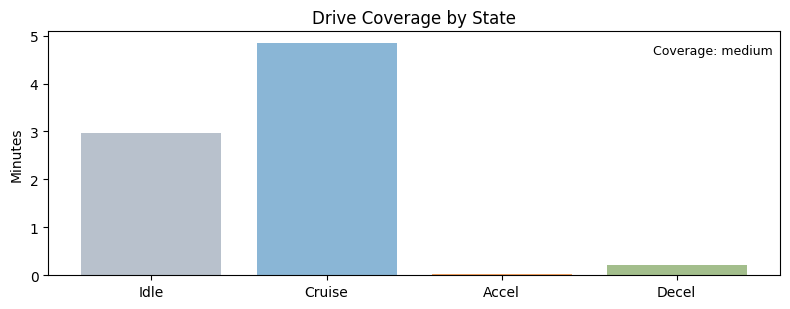

**Interpretation:** This log has moderate coverage. It is useful for context, but the absence of anomalies is still less informative than a longer log with more loaded operation.

### Recent Consistency

This section looks at the last up to 6 matching logs in the same bucket so a short or easy latest drive does not dominate the conclusion. It is meant to show whether issues are recurring, rare, or absent across recent comparable sessions.

,filename,date,duration_min,coverage,min_dam,fbk_count,fkl_count,max_iat_c,mean_ltft_pct,mean_stft_pct,max_load_proxy
0,datalog2.csv,2026-03-10,16.54,medium,0.875,0.0,2.0,25.0,4.685244,-0.700597,23.069448
1,datalog3.csv,2026-03-10,13.41,medium,0.875,0.0,11.0,31.0,6.084792,-0.957196,38.319071
2,datalog7.csv,2026-03-12,19.45,medium,0.750,37.0,6.0,32.0,6.374691,-0.129073,34.360674
3,datalog12.csv,2026-03-14,86.07,medium,0.625,783.0,156.0,37.0,5.864951,-0.488635,32.342575
4,datalog13.csv,2026-03-16,10.26,medium,1.000,0.0,0.0,31.0,-2.209485,-1.023367,36.759162
5,datalog14.csv,2026-03-16,8.04,medium,1.000,0.0,0.0,33.0,-1.170860,-1.570033,28.428800


**Interpretation:** Reviewed 6 recent cobb / cruising logs. DAM was below 1.0 in 4 of those logs. Meaningful FBK appeared in 2 logs and meaningful FKL appeared in 4 logs. Elevated IAT showed up in 0 logs and trim bias showed up in 3 logs.

### DAM Analysis

DAM (Dynamic Advance Multiplier) reflects ECU confidence in safe ignition advance on the FA20DIT. A DAM of 1.00 is the target full-confidence state, meaning the ECU is willing to carry its full learned timing authority. Drops below 1.00 indicate reduced confidence, with progressively lower values meaning the ECU has become more conservative about knock risk.

**Interpretation:** DAM stayed in the ideal range throughout the session.

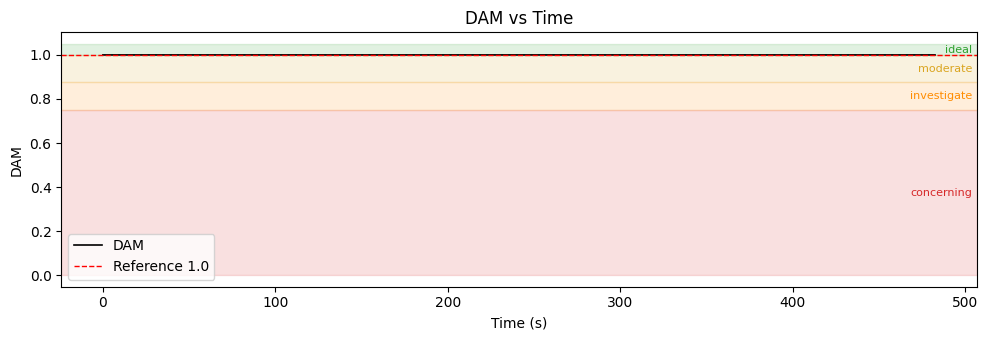

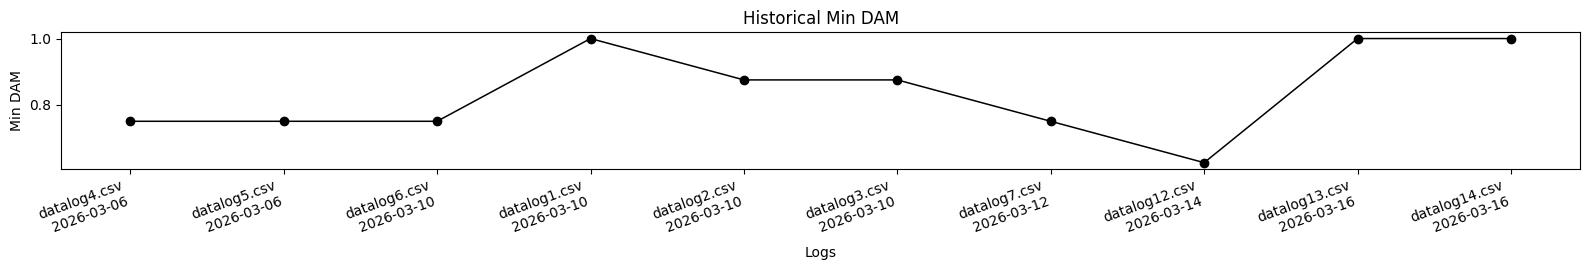

### FBK Analysis

FBK (Feedback Knock) is immediate timing pull when the FA20DIT ECU reacts to knock in the moment. It is the fast, short-term correction channel, so brief dips can happen without becoming a long-term issue. Deeper or repeated negative values matter more because they show the ECU actively removing timing under current load and RPM conditions.

**Interpretation:** FBK stayed in the ideal zone; only very small or no instantaneous correction was present.

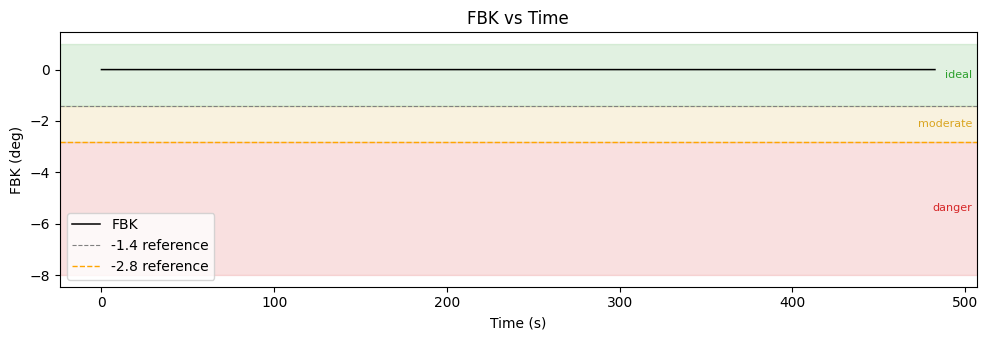

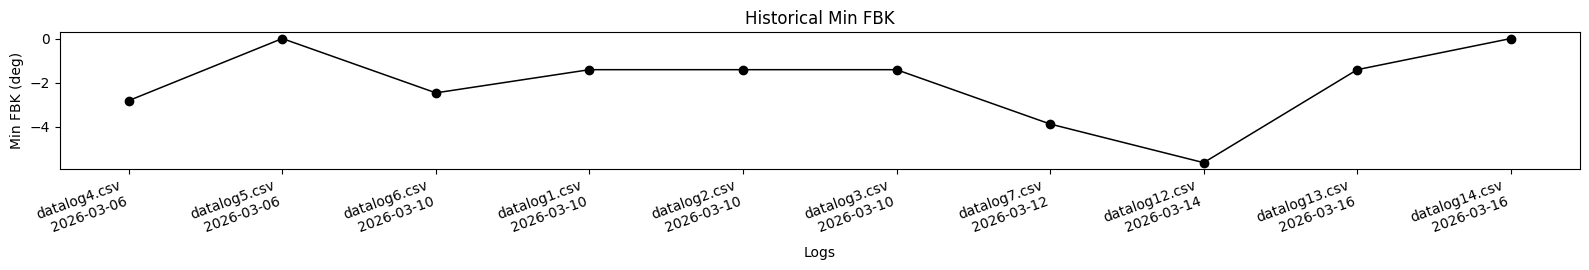

### FKL Analysis

FKL (Fine Knock Learn) is retained learned correction in repeated RPM/load cells on the FA20DIT. Unlike FBK, which is immediate, FKL shows where the ECU has learned that certain operating regions need ongoing correction. That makes it useful for identifying persistent problem zones rather than one-off transients.

**Interpretation:** FKL stayed in the ideal zone; no meaningful learned correction was recorded.

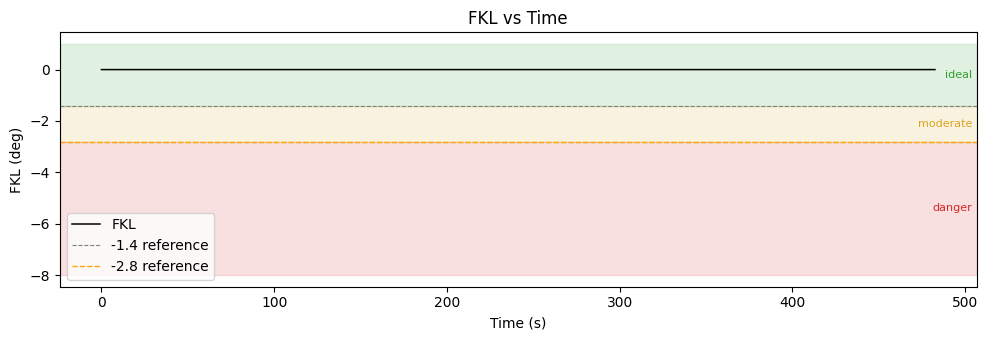

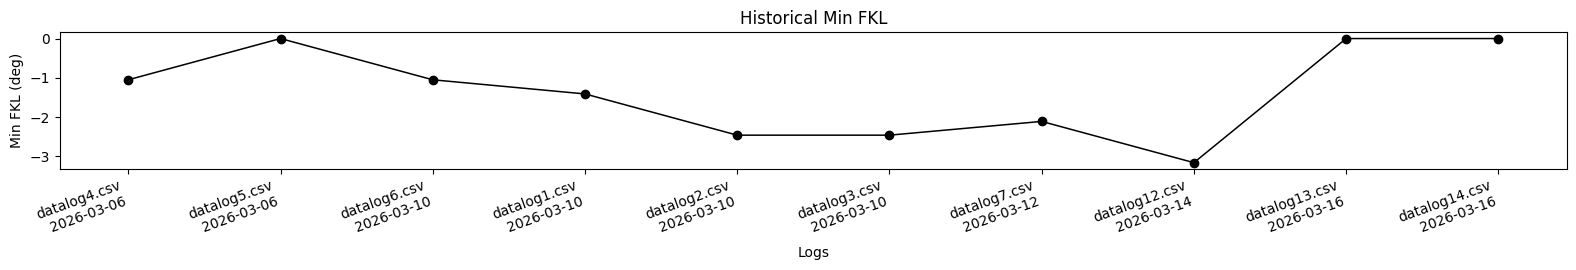

### Engine Risk

Load proxy is calculated as maf_gps / rpm * 1000 and serves as a simple airflow-per-revolution demand indicator. It is useful for describing how hard the engine was being asked to work, but it is not a direct safety limit by itself. The load bands in this report are descriptive only and should be interpreted together with MAP, IAT, DAM, and knock correction.

**Interpretation:** Engine load reached the high range and reflects meaningful boost/load use.

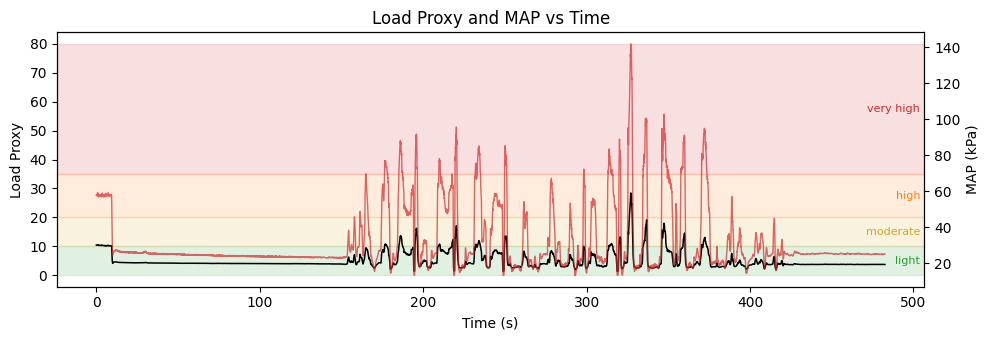

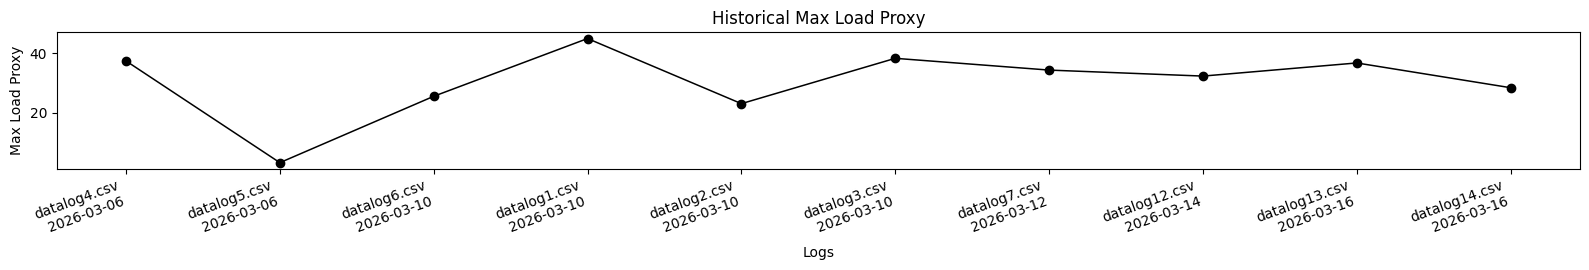

### RPM Context

These RPM-relative views show how airflow, manifold pressure, and meaningful knock activity are distributed across the rev range. The density plots make it easier to see where the engine spent most of its operating time, rather than over-emphasizing isolated points. The knock histogram is useful for spotting RPM bands where correction clusters repeatedly.

**Interpretation:** Use this section to see whether any knock activity or airflow limitations are concentrated in a particular RPM region rather than spread evenly through the pull.

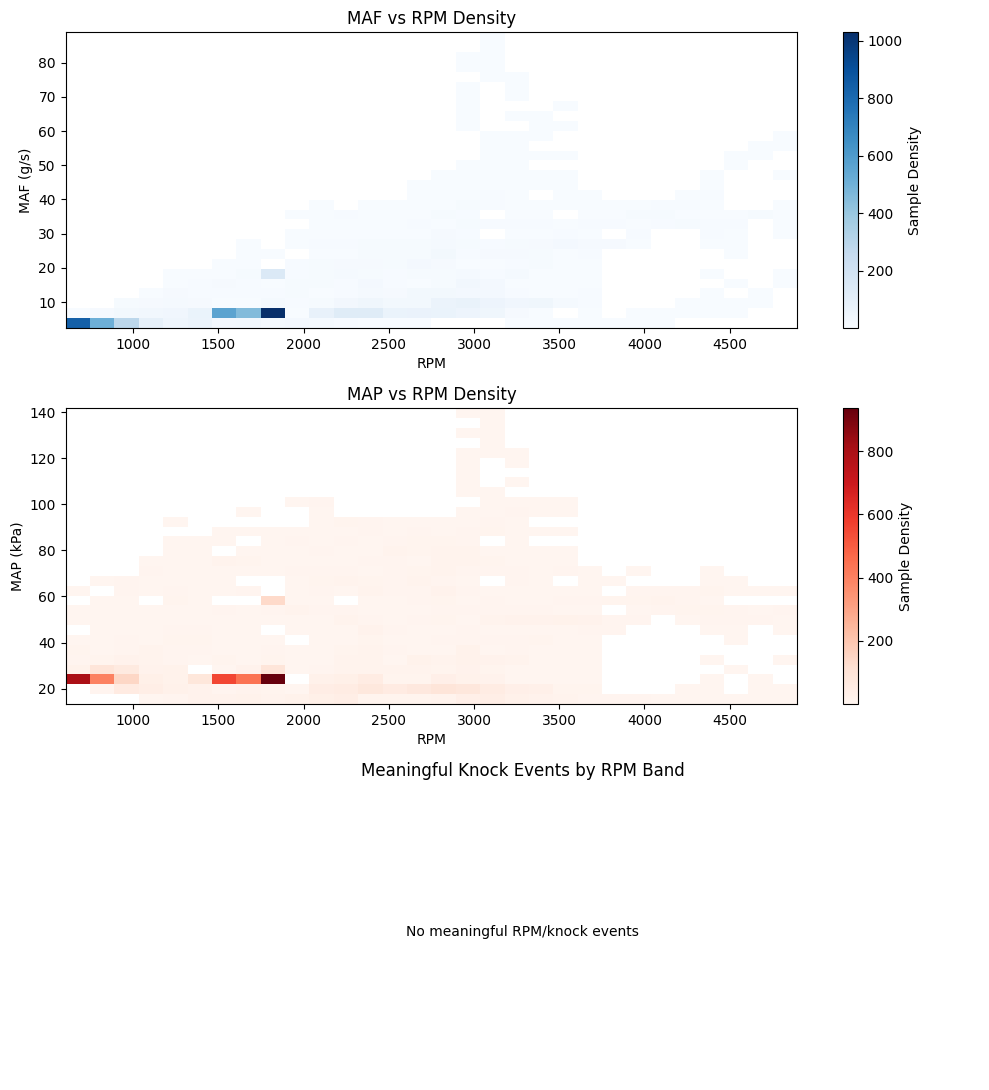

### Knock Context

This section captures where meaningful FBK, FKL, and DAM context points happened in the latest Cobb log. FBK and FKL counts here represent logged samples that crossed the event threshold, so one sustained correction can contribute multiple rows. DAM rows are narrower: they only mark DAM drop/change points below 1.0 plus the session minimum context, rather than every row where DAM stayed low. The plots are split by signal and severity, and they now include boost-at-event context using gauge boost derived from MAP. Estimated gear is approximate and is derived from RPM and vehicle speed using WRX drivetrain ratios.

**Interpretation:** No meaningful FBK/FKL events or DAM changes below 1.0 were recorded in this log.

No meaningful FBK/FKL events or DAM changes below 1.0 were detected in this log.

#### DAM Context

...

_No FKL context events for this log._

**Summary:** No FKL context events were recorded in this log.

### Coolant Analysis

Coolant temperature reflects the bulk operating temperature of the FA20DIT engine. It tells you how much thermal load the cooling system and engine block were carrying over the drive. Sustained elevation matters because coolant heat is slower-moving and more representative of overall engine thermal stress than transient intake heat.

**Interpretation:** Coolant stayed in the ideal FA20DIT operating band.

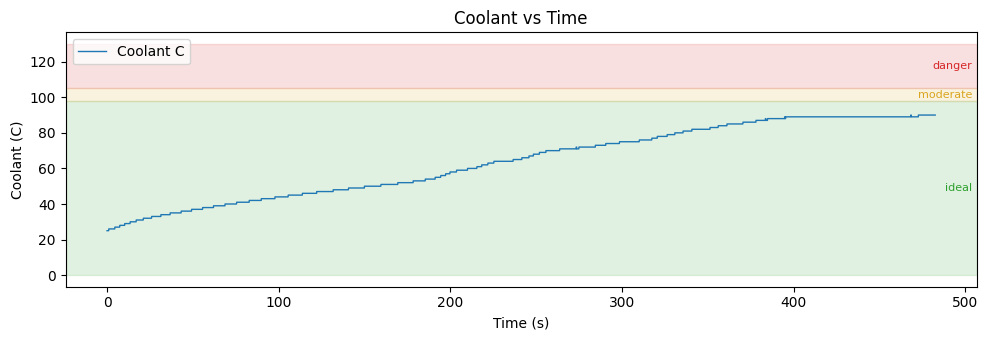

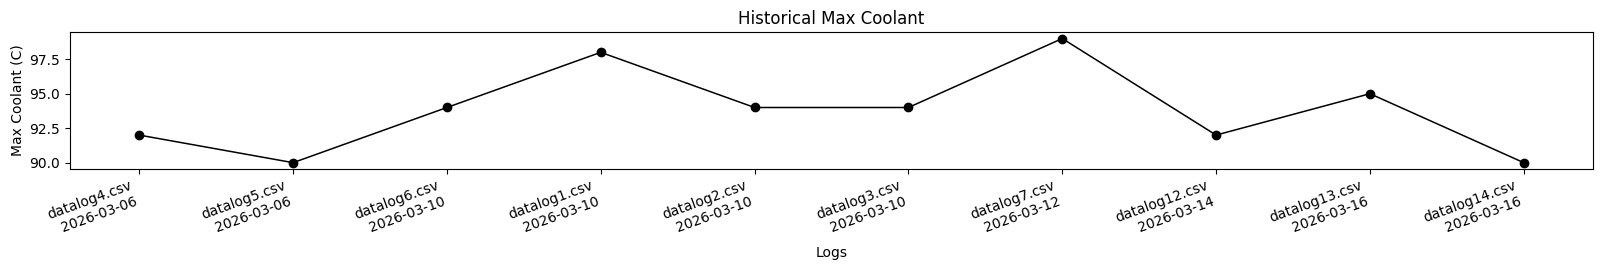

### IAT Analysis

Intake air temperature reflects how hot the intake charge became before combustion. On a turbo FA20DIT this matters because hotter intake charge generally reduces knock margin and can change how aggressively the ECU can hold timing. IAT also reacts faster than coolant, so it is useful for spotting heat soak and repeated boost exposure.

**Interpretation:** IAT stayed in the ideal FA20DIT range for this dataset.

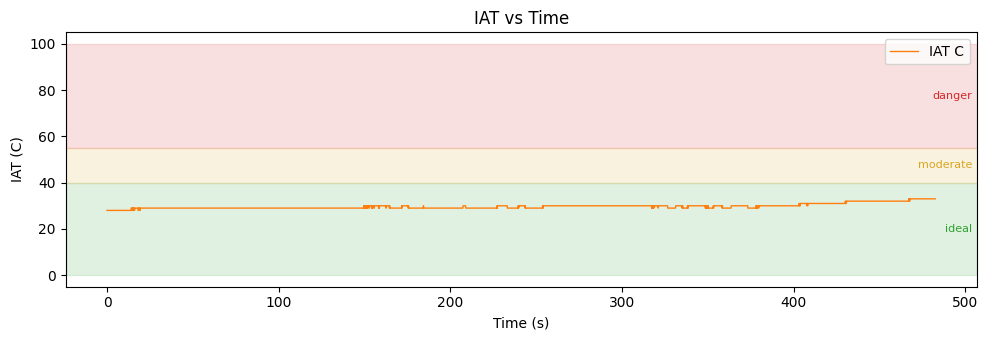

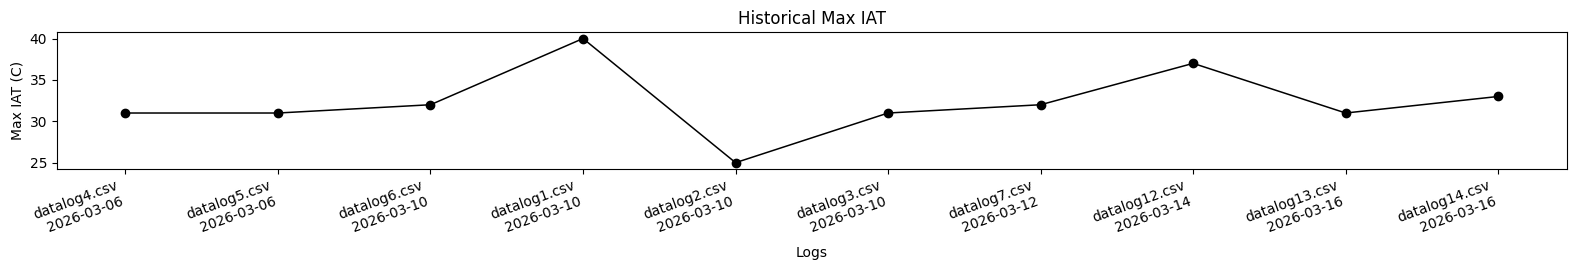

### Fuel Trim Analysis

STFT and LTFT show how much fueling correction the ECU needed relative to its base model. On Subaru logs, STFT corresponds to AF Correction 1 and LTFT corresponds to AF Learning 1. The combined plots below let you see both the immediate correction and the learned fueling bias together, including how they behave during idle, cruise, accel, and decel.

**Interpretation:** Fuel trims stayed in the ideal zone and look broadly stable.

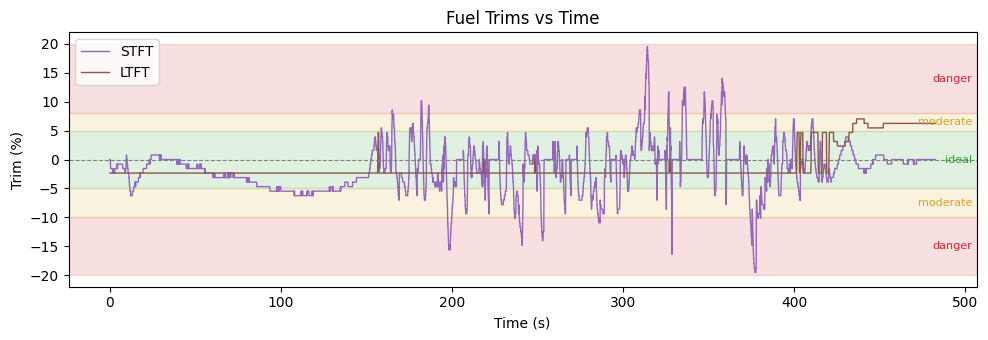

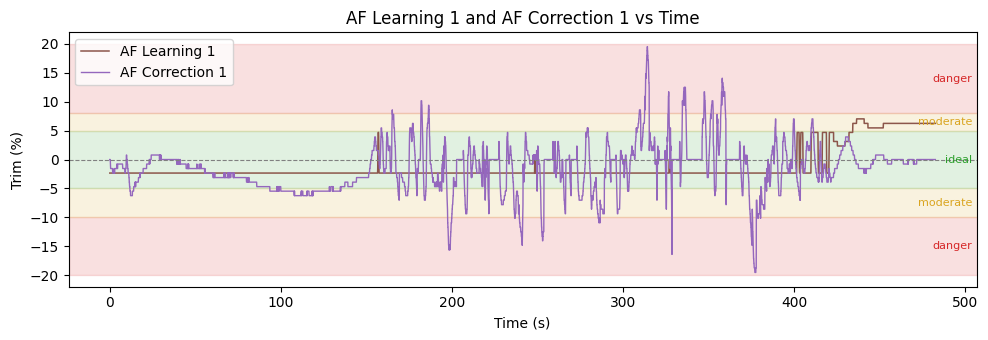

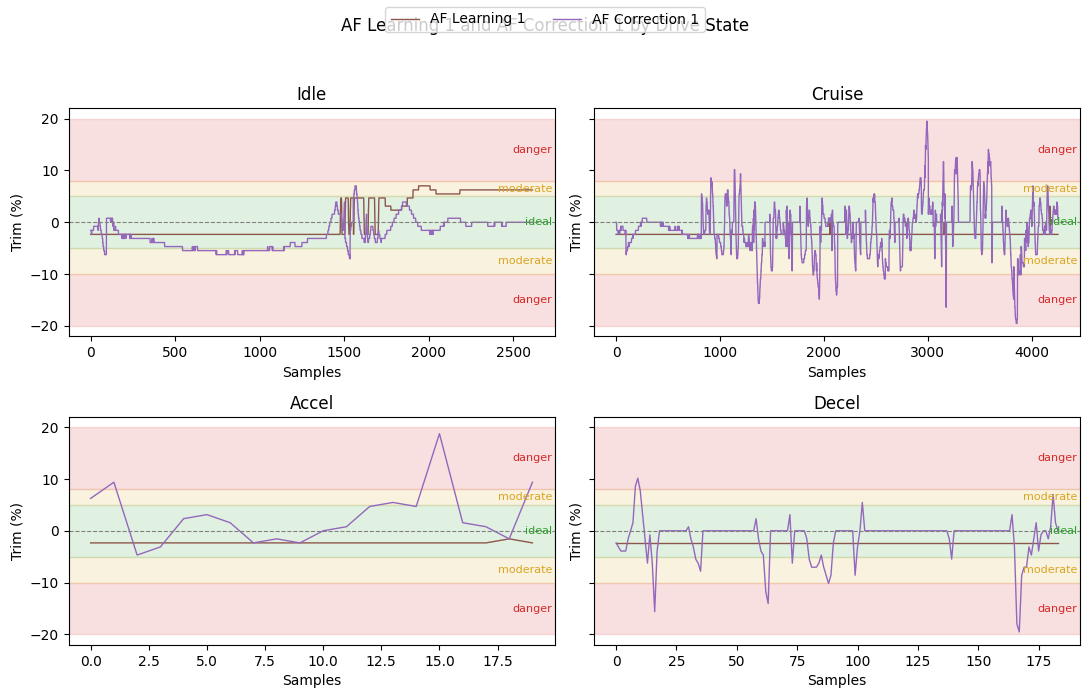

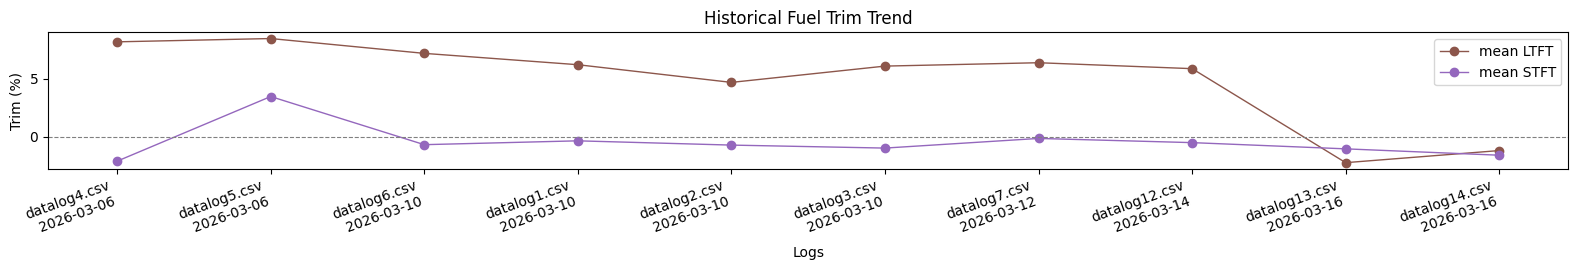

## COBB / racing

,filename,log_datetime,log_type,session_type,era_id,datetime_source,recent_event_context
0,datalog11.csv,2026-03-14 20:21:33.668709,cobb,racing,era_0,mtime,


,metric,latest_value,baseline_median,delta
0,duration_s,145.481000,143.377000,2.104000
1,min_dam,0.625000,0.750000,-0.125000
2,final_dam,0.625000,0.750000,-0.125000
3,min_fbk,-2.810000,-2.810000,0.000000
4,min_fkl,-3.160000,-2.110000,-1.050000
5,meaningful_fbk_count,8.000000,26.000000,-18.000000
6,meaningful_fkl_count,43.000000,58.000000,-15.000000
7,max_load_proxy,40.411880,39.826790,0.585090
8,p95_load_proxy,27.858557,22.942997,4.915560
9,max_maf,182.370000,191.170000,-8.800000


**Baseline comparison uses up to 6 prior matching logs. Confidence is normal.**

### Drive Coverage

Drive coverage summarizes how informative the latest session was. Short logs with little time above moderate throttle or mid-range RPM can look clean simply because they did not exercise the engine enough to reveal issues. This section separates useful latest-log coverage from sessions that should be treated as low-confidence snapshots.

,metric,value
0,Total duration (min),2.43
1,Moving time (min),1.1
2,Idle time (min),1.17
3,Cruise time (min),1.11
4,Accel time (min),0.09
5,Decel time (min),0.06
6,High-load time (min),0.12
7,High-load share (%),5.1
8,Estimated pulls,47
9,Longest pull (s),0.5


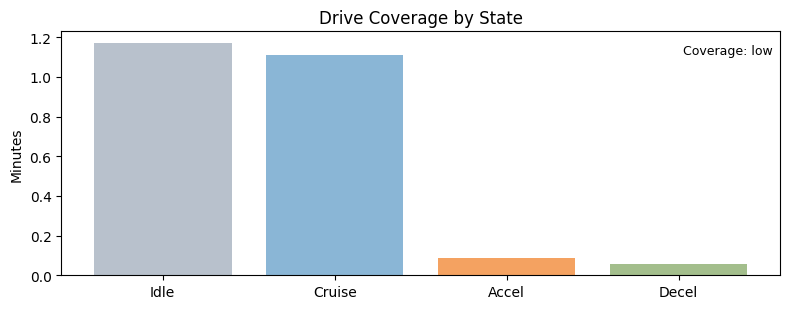

**Interpretation:** This log provides limited coverage. A clean latest log here should not be treated as strong evidence that the car is issue-free.

### Recent Consistency

This section looks at the last up to 6 matching logs in the same bucket so a short or easy latest drive does not dominate the conclusion. It is meant to show whether issues are recurring, rare, or absent across recent comparable sessions.

,filename,date,duration_min,coverage,min_dam,fbk_count,fkl_count,max_iat_c,mean_ltft_pct,mean_stft_pct,max_load_proxy
0,datalog8.csv,2026-03-14,10.40,high,0.750,83.0,261.0,58.0,7.915114,-0.163243,42.772885
1,datalog9.csv,2026-03-14,2.39,low,0.750,26.0,58.0,59.0,10.170322,-0.704409,39.132923
2,datalog11.csv,2026-03-14,2.42,low,0.625,8.0,43.0,60.0,8.727977,1.034970,40.411880
3,datalog10.csv,2026-03-14,2.18,low,0.625,0.0,51.0,59.0,8.889689,-0.425433,39.826790


**Interpretation:** Reviewed 4 recent cobb / racing logs. DAM was below 1.0 in 4 of those logs. Meaningful FBK appeared in 3 logs and meaningful FKL appeared in 4 logs. Elevated IAT showed up in 4 logs and trim bias showed up in 4 logs. 3 recent logs had low drive coverage, so trend confidence is lower than ideal.

### DAM Analysis

DAM (Dynamic Advance Multiplier) reflects ECU confidence in safe ignition advance on the FA20DIT. A DAM of 1.00 is the target full-confidence state, meaning the ECU is willing to carry its full learned timing authority. Drops below 1.00 indicate reduced confidence, with progressively lower values meaning the ECU has become more conservative about knock risk.

**Interpretation:** DAM finished in the concerning range, which indicates materially reduced ECU confidence.

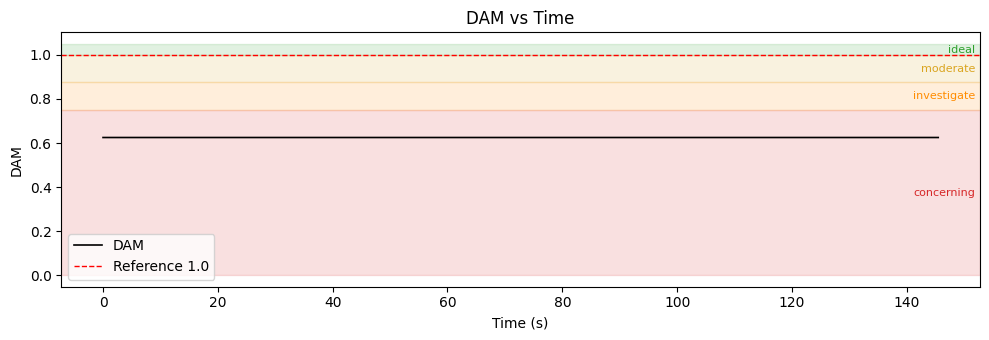

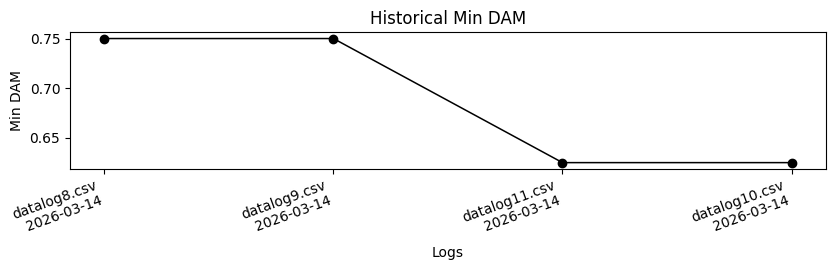

### FBK Analysis

FBK (Feedback Knock) is immediate timing pull when the FA20DIT ECU reacts to knock in the moment. It is the fast, short-term correction channel, so brief dips can happen without becoming a long-term issue. Deeper or repeated negative values matter more because they show the ECU actively removing timing under current load and RPM conditions.

**Interpretation:** FBK reached the FA20DIT danger zone, meaning deeper instantaneous timing pull occurred.

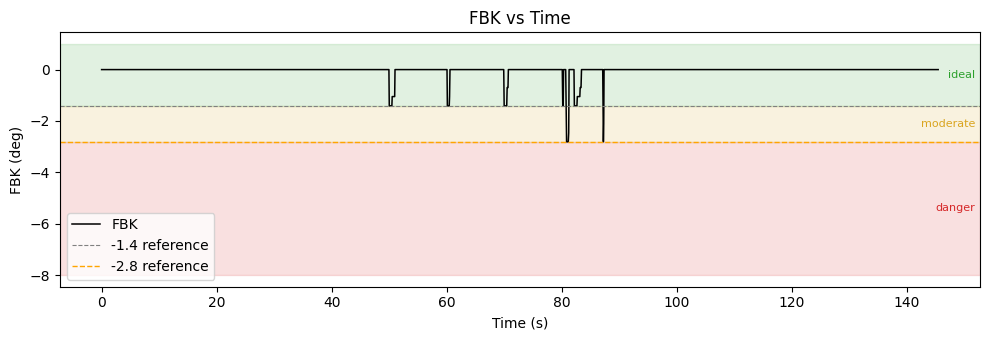

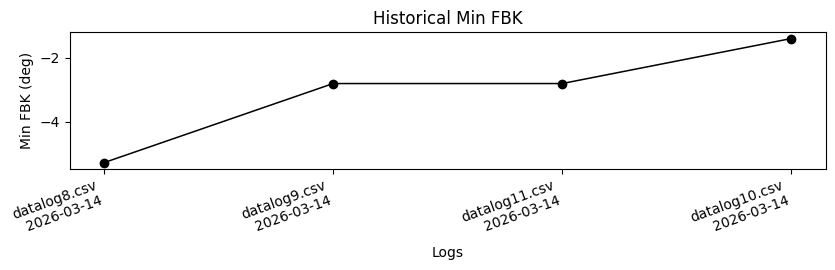

### FKL Analysis

FKL (Fine Knock Learn) is retained learned correction in repeated RPM/load cells on the FA20DIT. Unlike FBK, which is immediate, FKL shows where the ECU has learned that certain operating regions need ongoing correction. That makes it useful for identifying persistent problem zones rather than one-off transients.

**Interpretation:** FKL entered the FA20DIT danger zone, suggesting stronger learned correction in repeated operating cells.

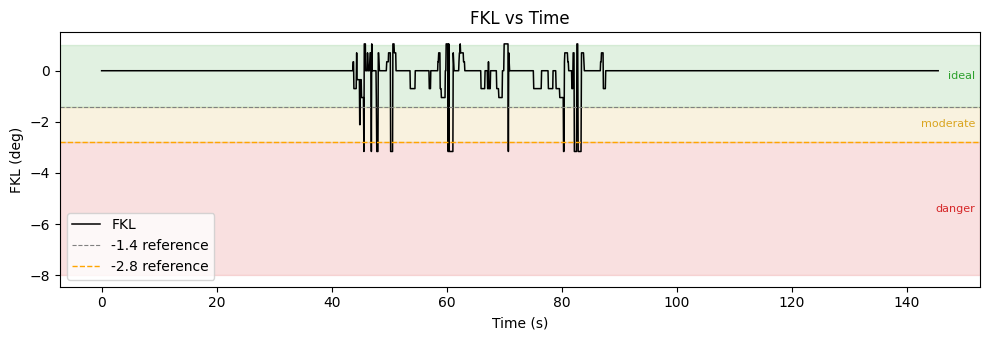

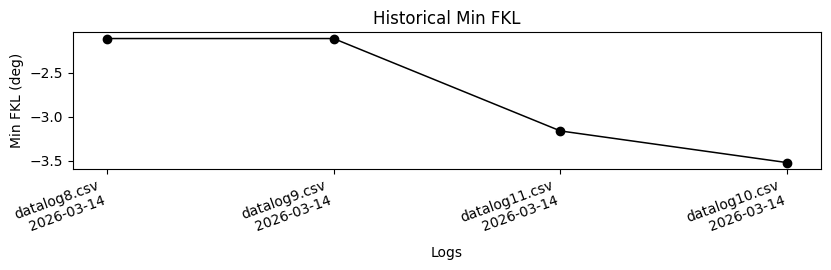

### Engine Risk

Load proxy is calculated as maf_gps / rpm * 1000 and serves as a simple airflow-per-revolution demand indicator. It is useful for describing how hard the engine was being asked to work, but it is not a direct safety limit by itself. The load bands in this report are descriptive only and should be interpreted together with MAP, IAT, DAM, and knock correction.

**Interpretation:** Engine load reached the very-high range and reflects hard-use operation, but this is descriptive rather than automatically unsafe.

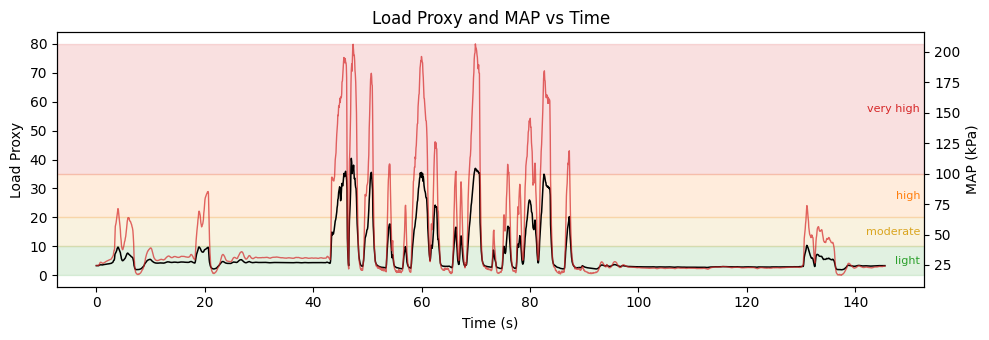

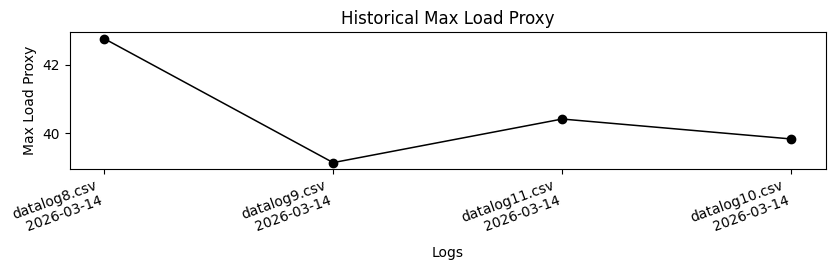

### RPM Context

These RPM-relative views show how airflow, manifold pressure, and meaningful knock activity are distributed across the rev range. The density plots make it easier to see where the engine spent most of its operating time, rather than over-emphasizing isolated points. The knock histogram is useful for spotting RPM bands where correction clusters repeatedly.

**Interpretation:** Use this section to see whether any knock activity or airflow limitations are concentrated in a particular RPM region rather than spread evenly through the pull.

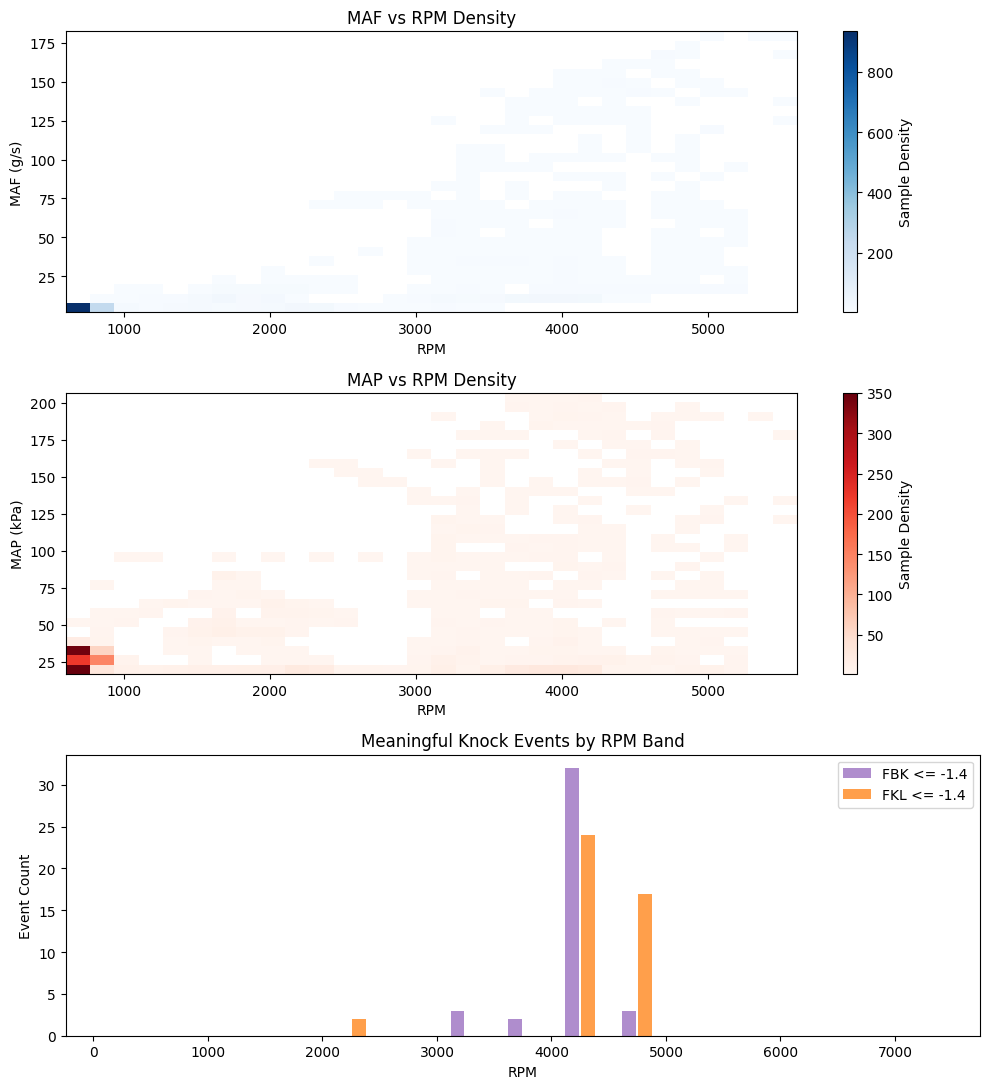

### Knock Context

This section captures where meaningful FBK, FKL, and DAM context points happened in the latest Cobb log. FBK and FKL counts here represent logged samples that crossed the event threshold, so one sustained correction can contribute multiple rows. DAM rows are narrower: they only mark DAM drop/change points below 1.0 plus the session minimum context, rather than every row where DAM stayed low. The plots are split by signal and severity, and they now include boost-at-event context using gauge boost derived from MAP. Estimated gear is approximate and is derived from RPM and vehicle speed using WRX drivetrain ratios.

**Interpretation:** Most knock/timing context events occurred outside stronger loaded operation or in mixed context. They clustered most in 500-1000 rpm. Estimated gear 2 captured the highest event count when estimable.

,event_type,value,time_s,rpm,gear_est,speed_mph,load_proxy,map_kpa,boost_actual_kpa,boost_actual_psi,boost_target_kpa,boost_error_kpa,throttle_pct,iat_c,state
0,DAM,0.62,0.00,712,NaN,0.0,3.29,24.55,-76.78,-11.14,-39.99,35.58,3.5,51.0,idle
1,DAM,0.62,0.05,710,NaN,0.0,3.30,24.55,-76.78,-11.14,-39.99,35.65,3.5,51.0,idle
2,DAM,0.62,0.12,709,NaN,0.0,3.29,24.48,-76.85,-11.15,-39.99,35.65,3.5,51.0,idle
3,DAM,0.62,0.20,708,NaN,0.0,3.29,24.48,-76.85,-11.15,-39.99,35.58,3.5,51.0,idle
4,DAM,0.62,0.29,709,NaN,0.0,3.29,24.55,-76.78,-11.14,-39.99,35.58,3.5,51.0,idle
5,DAM,0.62,0.36,709,NaN,0.0,3.29,24.61,-76.71,-11.13,-39.99,35.58,3.5,51.0,idle
6,DAM,0.62,0.46,703,NaN,0.0,3.30,24.61,-76.71,-11.13,-39.99,35.51,3.5,51.0,idle
7,DAM,0.62,0.54,702,NaN,0.0,3.45,25.10,-76.23,-11.06,-39.99,35.09,4.7,51.0,idle
8,DAM,0.62,0.63,706,NaN,0.0,3.54,26.27,-75.06,-10.89,-39.99,34.40,4.7,51.0,idle
9,DAM,0.62,0.70,725,NaN,0.0,3.57,26.96,-74.37,-10.79,-39.99,33.44,4.3,51.0,idle


_Showing first 20 rows of 2206 total context events._

#### DAM Context

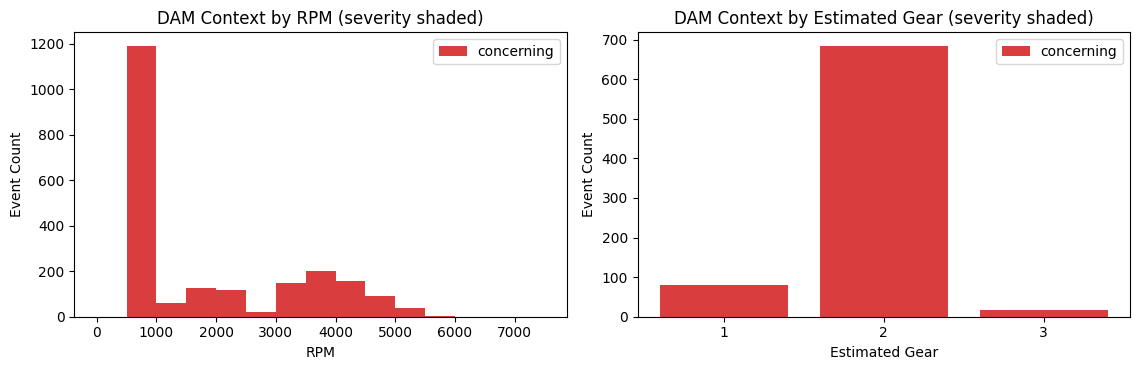

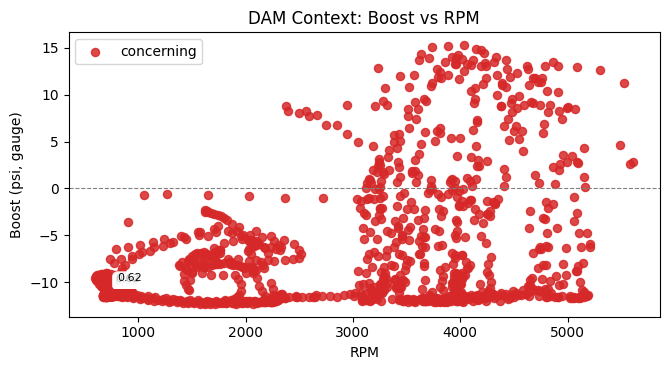

**Summary:** The most concerning DAM context points fell below 0.75. Events clustered most around 500-1000 rpm, most often in estimated gear 2, at about -10.7 psi median boost.

#### FBK Context

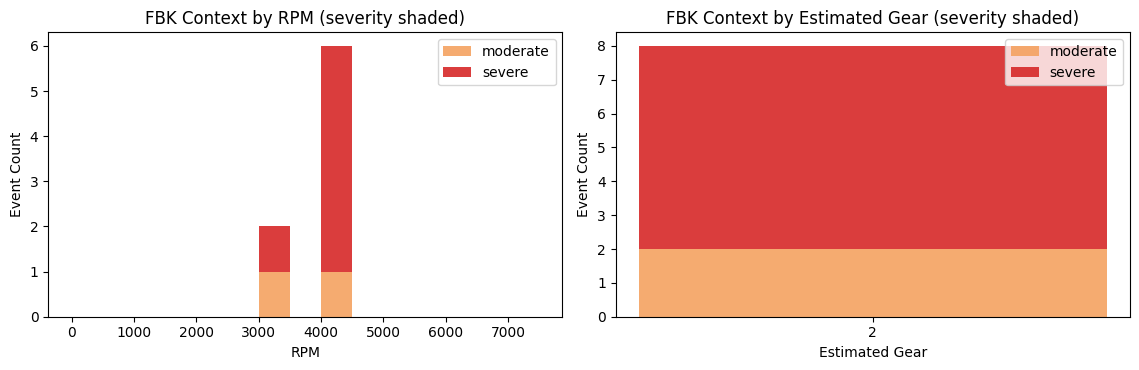

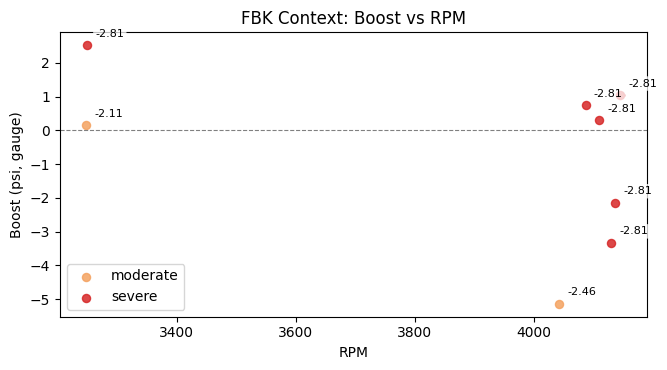

**Summary:** The deepest FBK events were in the severe range at or below -2.8 deg. Events clustered most around 4000-4500 rpm, most often in estimated gear 2, at about 0.2 psi median boost.

#### FKL Context

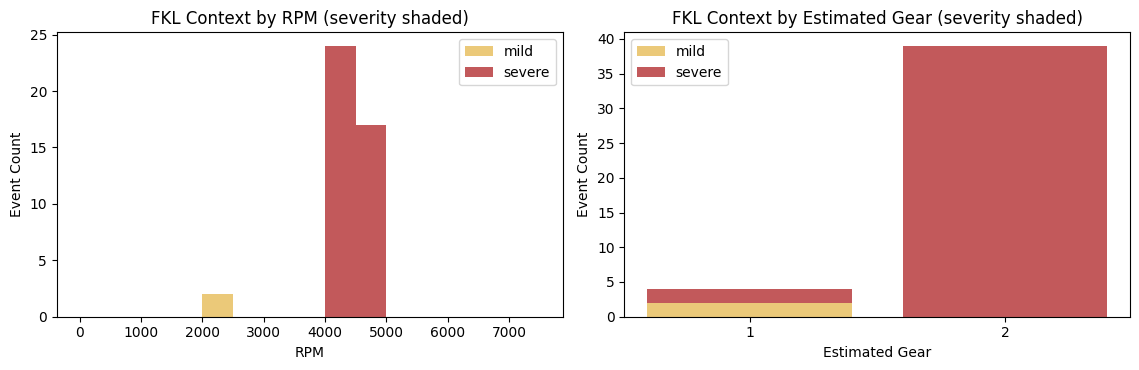

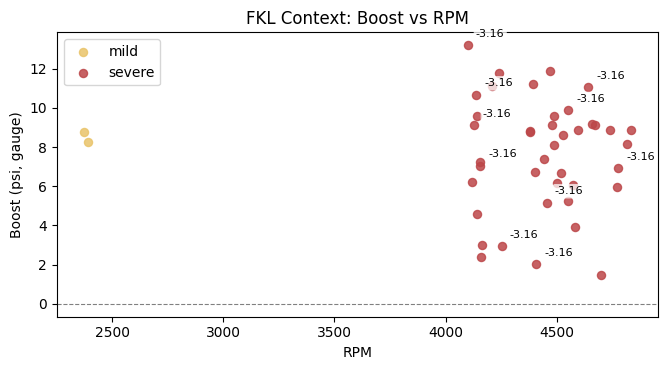

**Summary:** FKL learning reached the severe range at or below -2.8 deg. Events clustered most around 4000-4500 rpm, most often in estimated gear 2, at about 8.3 psi median boost.

### Coolant Analysis

Coolant temperature reflects the bulk operating temperature of the FA20DIT engine. It tells you how much thermal load the cooling system and engine block were carrying over the drive. Sustained elevation matters because coolant heat is slower-moving and more representative of overall engine thermal stress than transient intake heat.

**Interpretation:** Coolant stayed in the ideal FA20DIT operating band.

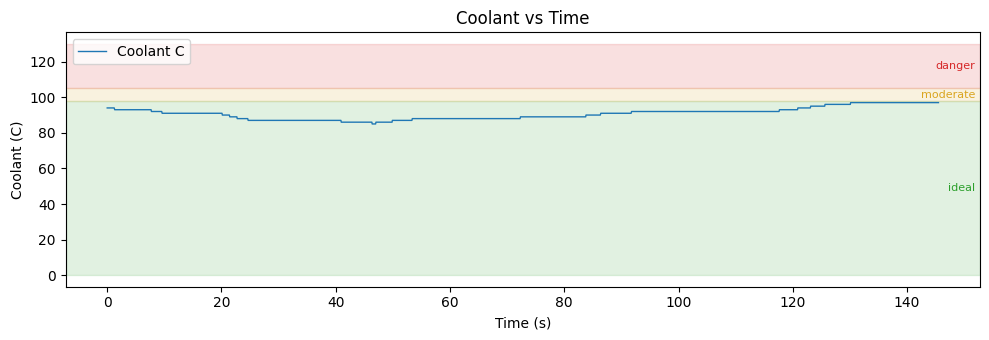

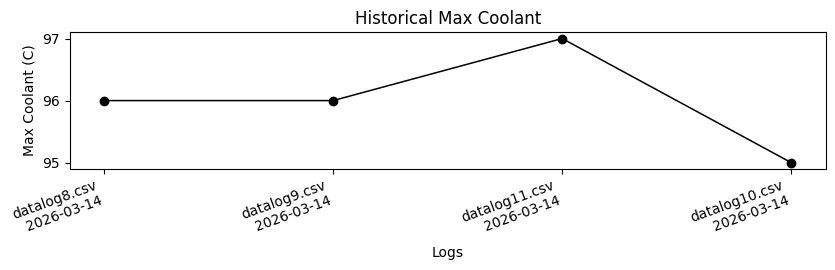

### IAT Analysis

Intake air temperature reflects how hot the intake charge became before combustion. On a turbo FA20DIT this matters because hotter intake charge generally reduces knock margin and can change how aggressively the ECU can hold timing. IAT also reacts faster than coolant, so it is useful for spotting heat soak and repeated boost exposure.

**Interpretation:** IAT entered the FA20DIT danger zone, which suggests notable heat soak or hot ambient/load conditions.

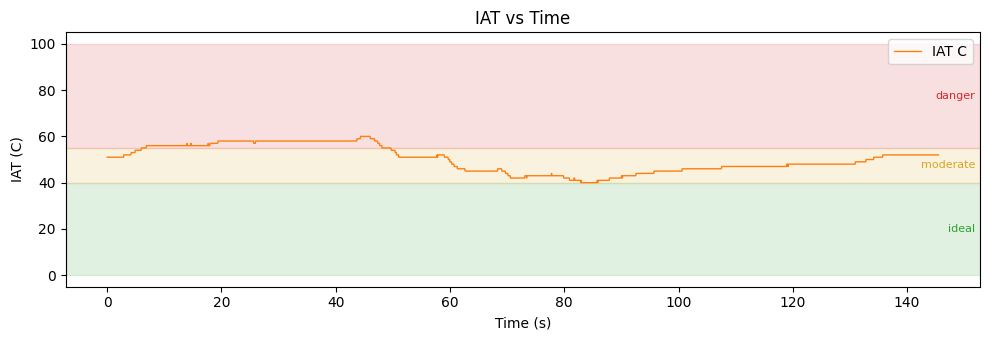

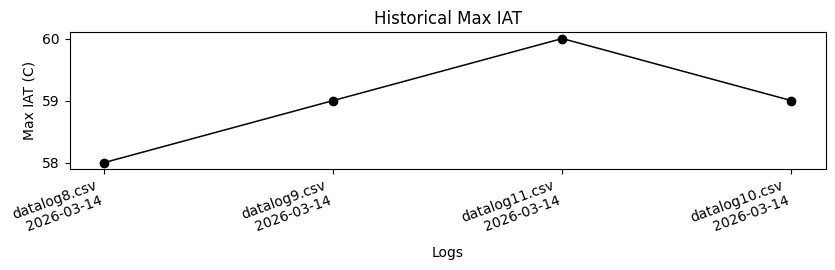

### Fuel Trim Analysis

STFT and LTFT show how much fueling correction the ECU needed relative to its base model. On Subaru logs, STFT corresponds to AF Correction 1 and LTFT corresponds to AF Learning 1. The combined plots below let you see both the immediate correction and the learned fueling bias together, including how they behave during idle, cruise, accel, and decel.

**Interpretation:** Fuel trims are in the FA20DIT danger zone and show a strong fueling bias worth investigating.

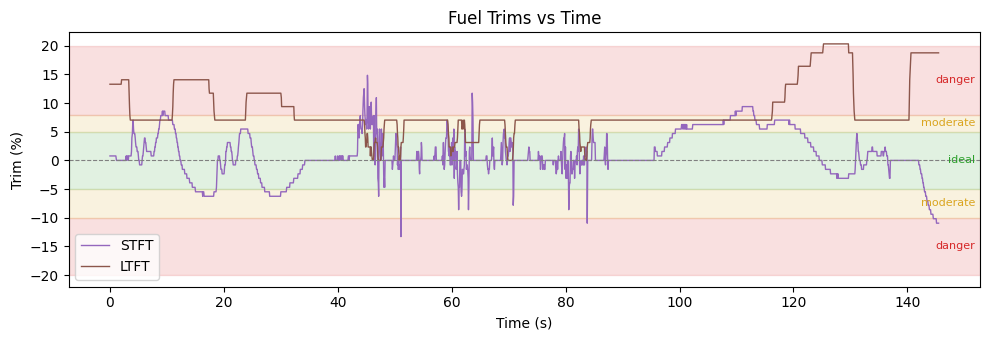

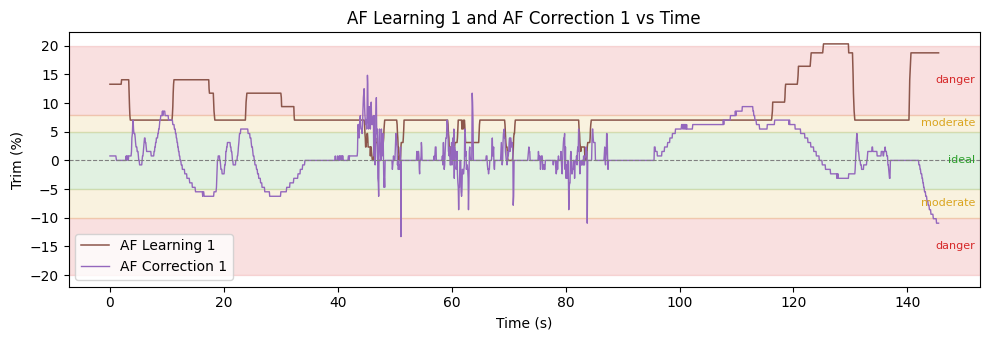

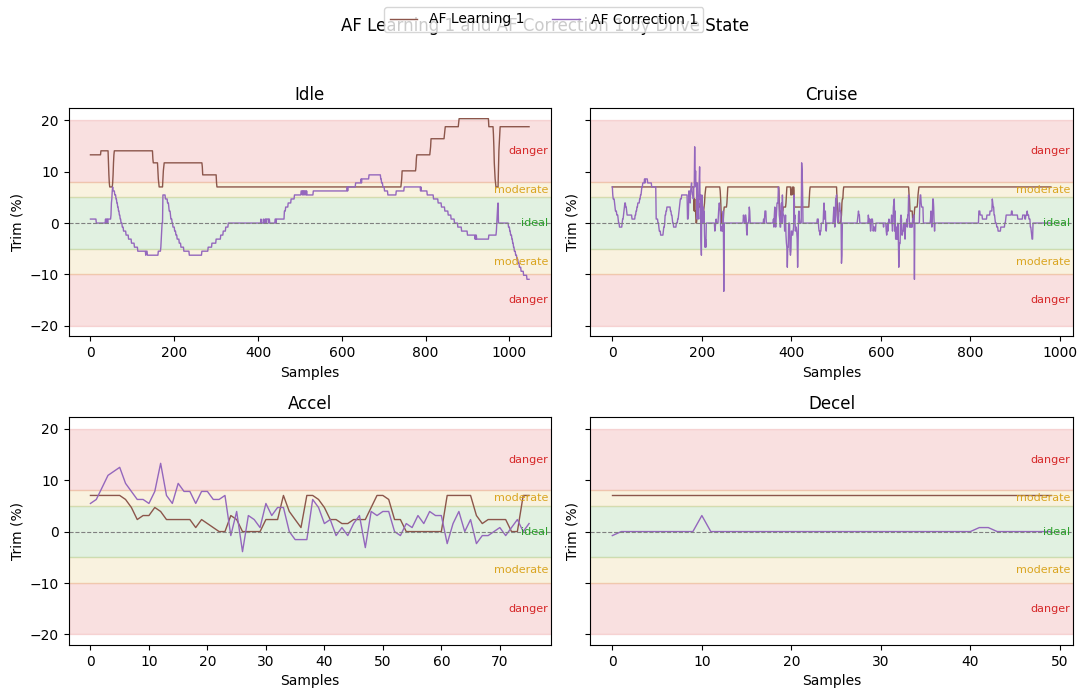

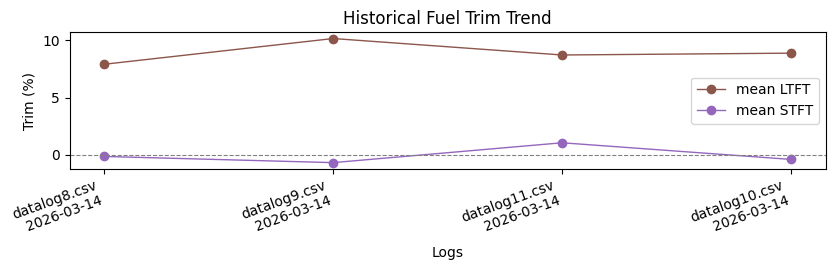

In [3]:
display(Markdown('## Cobb Data'))
found = False
for bucket in [('cobb', 'cruising'), ('cobb', 'racing')]:
    latest = latest_map[bucket]
    if latest is None:
        continue
    found = True
    display(Markdown(f'## {bucket[0].upper()} / {bucket[1]}'))
    _display_cobb_bucket(bucket, latest, baseline_map[bucket], frames[latest['log_id']])
if not found:
    print('No Cobb logs found.')


## OBD Data

## OBD / cruising

,filename,log_datetime,log_type,session_type,era_id,datetime_source,recent_event_context
0,CSVLog_20260306_174931.csv,2026-03-06 17:49:31.303200,obd,cruising,era_0,content,


,metric,latest_value,baseline_median,delta
0,duration_s,697.190000,1000.130000,-302.940000
1,max_load_proxy,29.998001,38.318177,-8.320176
2,p95_load_proxy,12.265439,11.262280,1.003159
3,max_maf,112.530000,170.650000,-58.120000
4,p95_maf,31.640500,34.030000,-2.389500
5,max_map_kpa,157.000000,188.000000,-31.000000
6,total_air_mass_g,6781.611070,11339.479900,-4557.868830
7,max_iat_c,52.000000,40.000000,12.000000
8,max_coolant_c,92.000000,94.000000,-2.000000
9,mean_ltft_pct,7.559548,8.591375,-1.031828


**Baseline comparison uses up to 6 prior matching logs. Confidence is limited because fewer than 3 were available.**

### Drive Coverage

Drive coverage summarizes how informative the latest session was. Short logs with little time above moderate throttle or mid-range RPM can look clean simply because they did not exercise the engine enough to reveal issues. This section separates useful latest-log coverage from sessions that should be treated as low-confidence snapshots.

,metric,value
0,Total duration (min),11.63
1,Moving time (min),6.5
2,Idle time (min),4.46
3,Cruise time (min),6.45
4,Accel time (min),0.72
5,Decel time (min),0.0
6,High-load time (min),0.58
7,High-load share (%),5.0
8,Estimated pulls,1
9,Longest pull (s),0.7


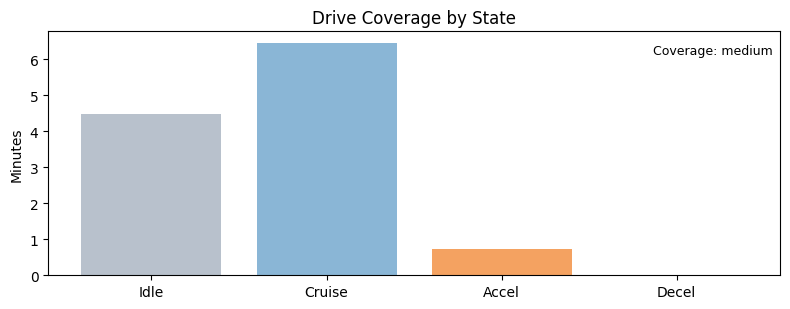

**Interpretation:** This log has moderate coverage. It is useful for context, but the absence of anomalies is still less informative than a longer log with more loaded operation.

### Recent Consistency

This section looks at the last up to 6 matching logs in the same bucket so a short or easy latest drive does not dominate the conclusion. It is meant to show whether issues are recurring, rare, or absent across recent comparable sessions.

,filename,date,duration_min,coverage,min_dam,fbk_count,fkl_count,max_iat_c,mean_ltft_pct,mean_stft_pct,max_load_proxy
0,First log 3_4_26.csv,2026-03-05,16.67,medium,NaN,NaN,NaN,40.0,8.591375,-0.851895,38.318177
1,CSVLog_20260306_174931.csv,2026-03-06,11.62,medium,NaN,NaN,NaN,52.0,7.559548,-1.006005,29.998001


**Interpretation:** Reviewed 2 recent obd / cruising logs. Elevated IAT showed up in 1 logs and trim bias showed up in 2 logs.

### Engine Risk

OBD logs do not include Subaru-specific DAM, FBK, or FKL channels here, so risk has to be inferred from load_proxy, MAP, MAF, and time spent at higher demand. That means this section is best used to understand how hard the engine was working, not to make a direct knock-confidence judgment. It is still useful for separating easy cruising from more boost-heavy or airflow-heavy sessions.

**Interpretation:** Engine load reached the high range and reflects meaningful boost/load use.

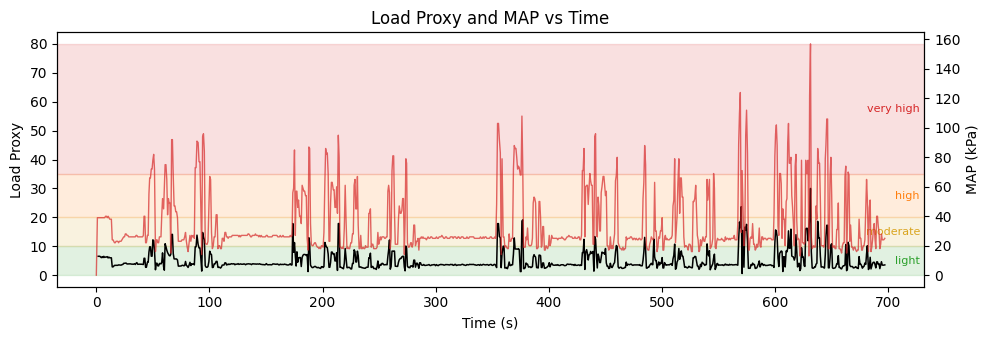

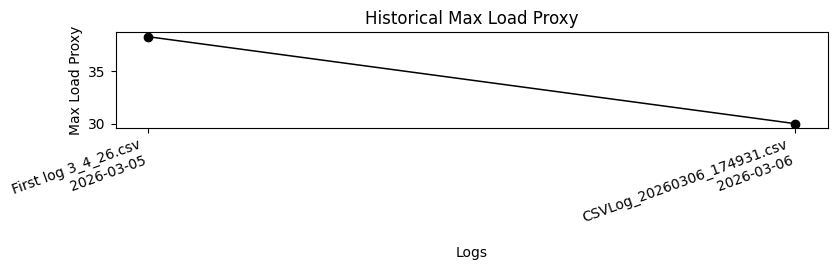

### RPM Context

These RPM-relative views show how airflow, manifold pressure, and meaningful knock activity are distributed across the rev range. The density plots make it easier to see where the engine spent most of its operating time, rather than over-emphasizing isolated points. The knock histogram is useful for spotting RPM bands where correction clusters repeatedly.

**Interpretation:** Use this section to see whether any knock activity or airflow limitations are concentrated in a particular RPM region rather than spread evenly through the pull.

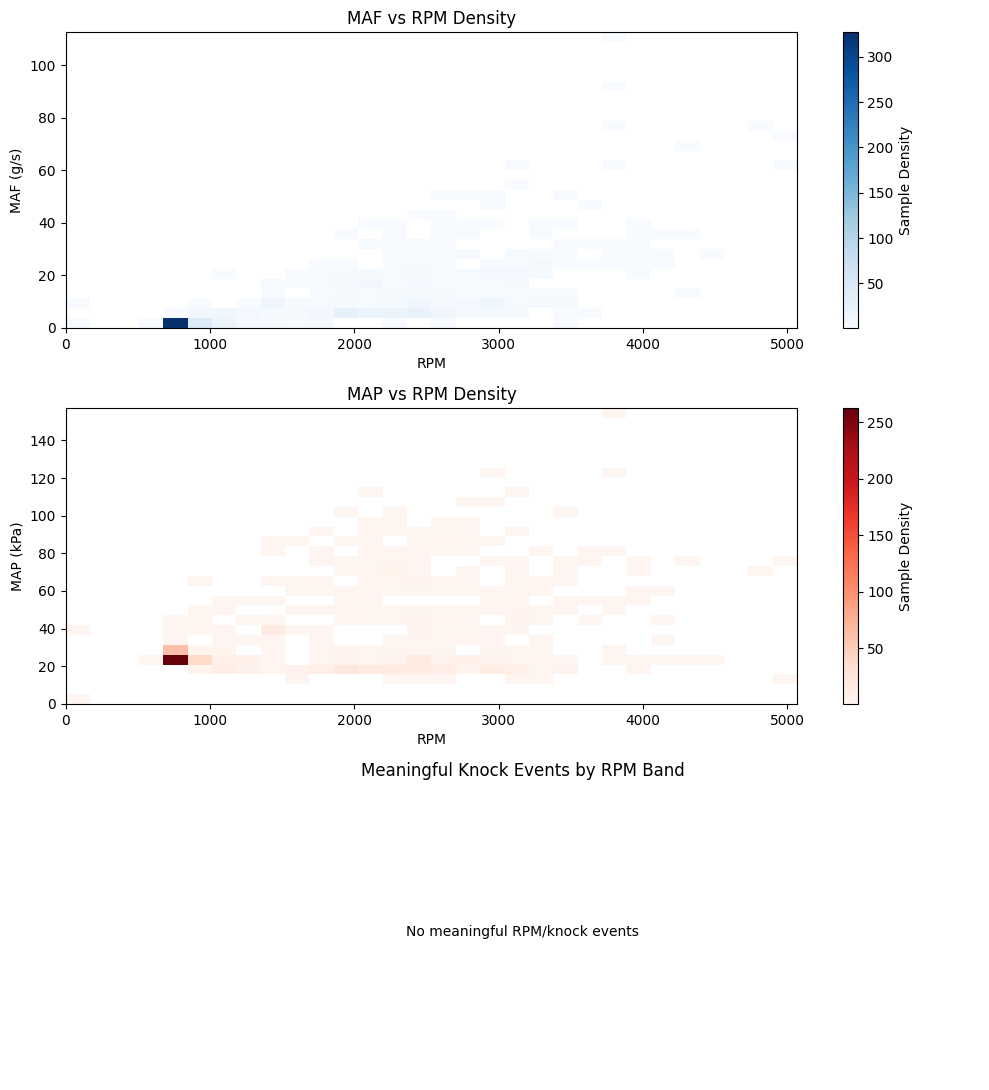

### Coolant Analysis

OBD coolant temperature shows the engine's bulk operating temperature even when Subaru knock channels are unavailable. It is one of the better general health indicators in reduced-detail logs because it captures sustained thermal load. If coolant trends higher than expected for similar sessions, that can be a sign to inspect operating conditions or cooling performance.

**Interpretation:** Coolant stayed in the ideal FA20DIT operating band.

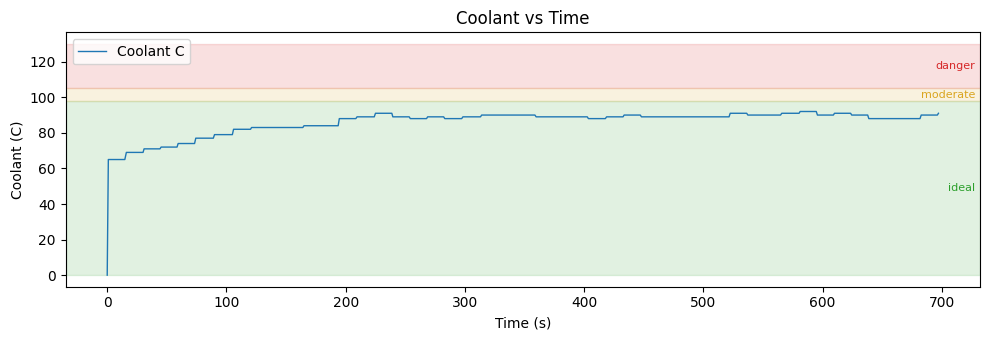

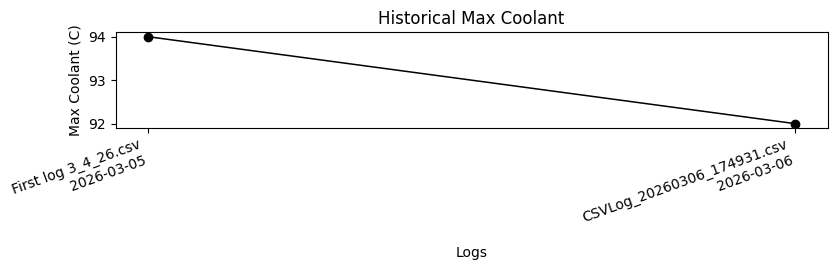

### IAT Analysis

OBD intake air temperature shows how hot the intake charge became during the drive. On the FA20DIT, elevated IAT reduces knock margin even if you cannot see DAM or knock correction directly in the OBD log. That makes it an important context metric for judging whether the engine was operating in a heat-soaked state.

**Interpretation:** IAT entered the moderate zone but did not reach a severe level.

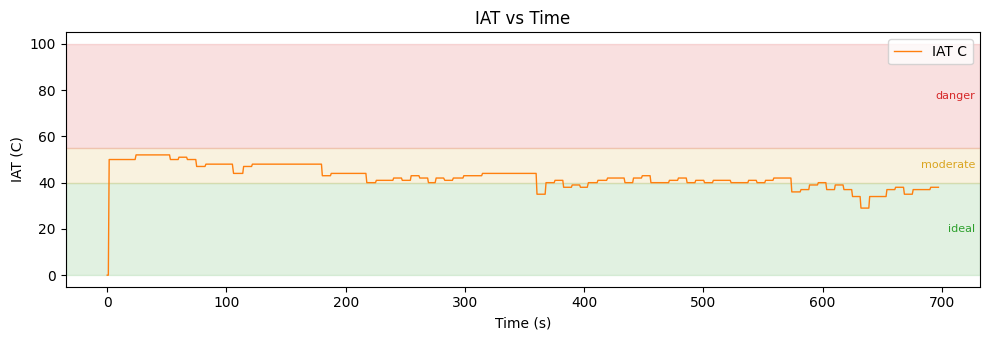

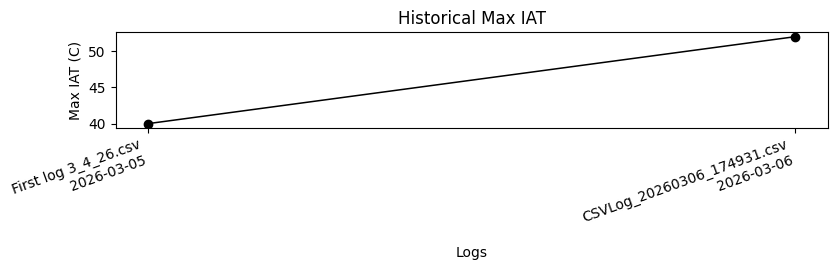

### Fuel Trim Analysis

OBD short- and long-term fuel trims show whether the ECU had to add or remove fuel over the drive to stay on target. STFT captures immediate correction and LTFT captures learned bias over time. In reduced-detail logs, trims are one of the most useful indicators for whether fueling behavior remains centered or has started to drift.

**Interpretation:** Fuel trims are in the moderate zone and show some bias, but not an extreme one.

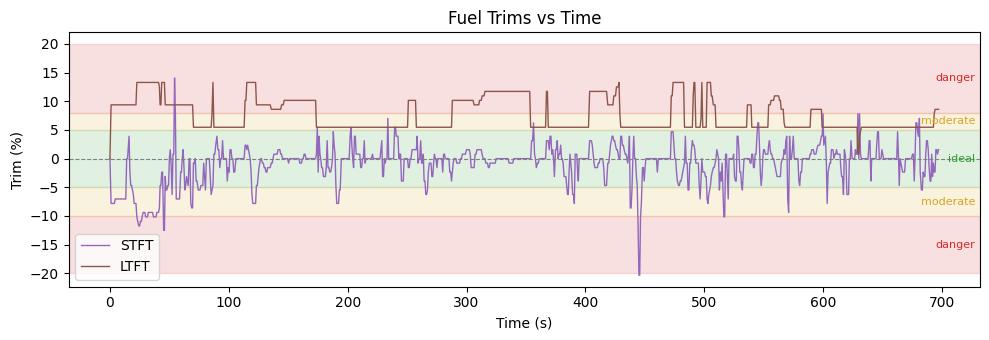

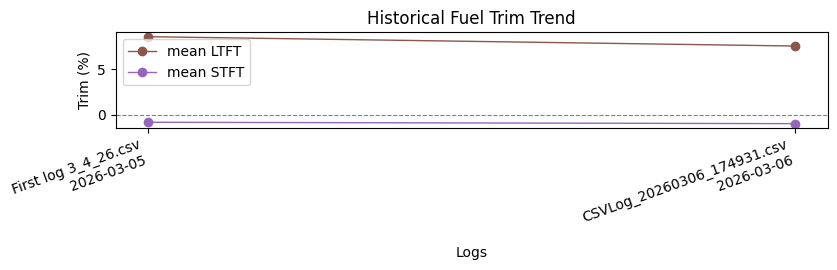

In [4]:
display(Markdown('## OBD Data'))
found = False
for bucket in [('obd', 'cruising'), ('obd', 'racing')]:
    latest = latest_map[bucket]
    if latest is None:
        continue
    found = True
    display(Markdown(f'## {bucket[0].upper()} / {bucket[1]}'))
    _display_obd_bucket(bucket, latest, baseline_map[bucket], frames[latest['log_id']])
if not found:
    print('No OBD logs found.')


In [5]:
display(Markdown('## Metadata'))
display(summary_df[['filename','log_datetime','log_datetime_source','log_type','session_type','era_id','recent_event_context']])
baseline_rows = []
for bucket in BUCKETS:
    baseline = baseline_map[bucket]
    baseline_rows.append({
        'bucket': f'{bucket[0]}/{bucket[1]}',
        'baseline_count': len(baseline),
        'baseline_files': ', '.join(baseline['filename'].astype(str).tolist()) if not baseline.empty else '',
    })
display(pd.DataFrame(baseline_rows))
if not events_df.empty:
    display(events_df)
else:
    print('No events loaded from data/events.csv')


## Metadata

,filename,log_datetime,log_datetime_source,log_type,session_type,era_id,recent_event_context
0,First log 3_4_26.csv,2026-03-05 12:46:04.903200,content,obd,cruising,era_0,
1,datalog4.csv,2026-03-06 16:41:39.883284,mtime,cobb,cruising,era_0,
2,datalog5.csv,2026-03-06 16:41:39.916859,mtime,cobb,cruising,era_0,
3,CSVLog_20260306_174931.csv,2026-03-06 17:49:31.303200,content,obd,cruising,era_0,
4,datalog6.csv,2026-03-10 21:58:35.667806,mtime,cobb,cruising,era_0,
5,datalog1.csv,2026-03-10 21:59:14.595646,mtime,cobb,cruising,era_0,
6,datalog2.csv,2026-03-10 21:59:15.171155,mtime,cobb,cruising,era_0,
7,datalog3.csv,2026-03-10 21:59:15.622123,mtime,cobb,cruising,era_0,
8,datalog7.csv,2026-03-12 21:08:15.050882,mtime,cobb,cruising,era_0,
9,datalog8.csv,2026-03-14 20:13:53.255788,mtime,cobb,racing,era_0,


,bucket,baseline_count,baseline_files
0,cobb/cruising,6,"datalog4.csv, datalog5.csv, datalog6.csv, data..."
1,cobb/racing,3,"datalog8.csv, datalog9.csv, datalog10.csv"
2,obd/cruising,1,First log 3_4_26.csv
3,obd/racing,0,


No events loaded from data/events.csv
